# Final Project: Kalshi Market Making on Short-Dated SPX Price Events

Chris Mulligan (12502987), George Lord (12243747), Max Zhalilo (12341701)

In [35]:
# Initialize the project packages and environment
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display

import sys
sys.path.insert(0, "src")

from DataIngestor import DataIngestor, KalshiCleanSpec, MacroSpec
from Pricer import Pricer
from paper_functions import (
    format_summary,
    format_all_df_summary,
    plot_market_environment,
    kalshi_vwap,
    plot_trade_activity_by_hour,
    plot_trade_volume_by_contract_type,
    display_contract_samples,
    display_summary_table,
    display_all_df_overview,
    print_market_stats,
    print_trade_activity_stats,
    plot_intraday_price_convergence,
    plot_implied_probability_vs_distance,
    run_model_price_vs_market_section,
    run_main_results_overview,
    run_variant_results_overview,
    plot_rolling_drawdown,
    plot_inventory_and_spy_position,
    print_max_unique_kalshi_contracts_held,
    plot_total_kalshi_trade_volume_by_hour,
    plot_cumulative_trade_count_histogram,
    plot_average_pnl_by_hour,
    plot_average_spread_by_hour,
    plot_spread_for_date_est,
    compute_and_plot_returns_over_time,
    plot_return_histograms_with_percentiles,
    correlation_with_spx_and_scatter,
    correlation_with_spx_and_scatter_no_hedge,
    portfolio_ts,
    perf_stats,
    INITIAL_CAPITAL,
    ANN_SECONDS,
    final_pnl,
    var_cvar,
    get_daily_sharpe,
    get_hourly_rolling_sharpe,
    add_regime,
    adverse_deltas,
)

data_path = "Data/cleaned_parquets/"


# Contents

0. Abstract
1. Introduction
2. Data
3. Theory
4. Implementation
5. Results
6. References

# 0. Abstract

Kalshi is a CFTC-licensed web-based prediction market launched in 2021 in New York City. Prediction markets like Kalshi posted a record US$3.7 billion in weekly trading volume as of January 19, 2026, up from under $100M in 2024[1]. While sources attribute 90% of Kalshi's volume to sports-betting, the platform lists a growing number of contracts based on political events, popular culture, economics, and more [2]. Among these are contracts that pay out if the S&P 500 Index (SPX) value falls above a given threshold or within a given range. In an effort to capture short-term mispricings arising from retail flow and limited volume, we develop and present a historical performance analysis of a market-making model on these SPX event contracts. We begin by replicating these contracts to approximate risk-neutral prices as a function of binary put and call options on SPX. We then use historical SPX and VIX values as inputs to model SPX binary options prices as lognormal probabilities as implied by the Black-Scholes-Merton (BSM) model, providing causal fair price estimates for our Kalshi events over our time horizon. We proceed to simulate an automated strategy to market-make the Kalshi SPX events near 0-1 DTE around our fair price estimates, delta hedging SPX exposure with the SPY ETF and sizing risk based on VIX. Our simulator interfaces with trade-ready modules for execution, deterministically simulating step-by-step rule-based execution to replicate a live deployment as close as possible. Finally, we test the performance of our strategy over 2 months of recent market data (Jan 2026 through Feb 2026) and present a comprehensive analysis of our results.

# 1. Introduction

In modern financial markets, algorithmic trading and automated market making have become central components of liquidity provision and price discovery. As recently as February 2026, Electronic Market Makers such as Jump Trading & Virtu Financial have begun to expand into prediction markets such as Kalshi & Polymarket to profit from their increasing trading volumes [3]. In this project, we develop and test a fully systematic market-making strategy for short-dated S&P 500 (SPX) event contracts listed on Kalshi. These contracts pay a fixed $1 if a specified event occurs--such as the SPX closing above a certain level--and $0 otherwise. As a result, they can be interpreted as binary options, or combinations thereof, on the terminal value of the SPX index.

The core idea of our strategy is grounded in Black-Scholes-Merton (BSM) derivative pricing theory. A binary call option has a current value equal to the discounted risk-neutral probability that the underlying asset finishes above a given strike at expiration. For contracts with 0–1 days to expiration, discounting becomes negligible, and the contract price closely approximates the market-implied probability of the underlying event. By modeling the terminal distribution of SPX under a log-normal assumption consistent with the BSM framework, we can estimate these probabilities analytically using closed-form expressions. Specifically, we compute the Cumulative Distribution Function (CDF) implied by current SPX levels, time to expiration, and volatility, with volatility estimated by the VIX index.

Once historical fair values for the binary calls and puts on SPX at the corresponding expiration and strike prices are obtained, we replicate the payoff structures of Kalshi’s SPX “above” (KXINXU) and “range” (KXINX) contracts using combinations of these binaries [4] [5]. This replication framework provides a theoretical fair price for each listed contract. The strategy then centers its market-making quotes around these fair values and dynamically adjusts bid–ask spreads as a function of market volatility, time to expiration, tick size constraints, exchange fees, and current inventory. In higher-volatility or low-liquidity environments, spreads are widened to compensate for increased uncertainty and adverse selection risk.

Because the fair value of each contract is sensitive to movements in the underlying SPX index, holding inventory in Kalshi contracts introduces directional exposure. To manage this risk, we compute the delta of each replicated binary position with respect to SPX and aggregate the book’s total delta exposure. We then hedge this exposure using the SPY ETF, which closely tracks SPX movements. This delta-hedging process isolates the strategy’s profit and loss primarily to bid–ask spread capture and pricing inefficiencies rather than outright market direction.

We test our strategy in a simulator that mimics Kalshi exchange execution. Our strategy is implemented using pricing, market making, hedging, & position management modules, all of which interact with the simulator using our execution engine module. Our objective is to assess whether theoretically grounded probability estimates, combined with disciplined spread management and delta hedging, can generate consistent risk-adjusted returns in short-dated event markets.

# 2. Data

This section describes the five datasets used in our simulation, the structure of Kalshi SPX contracts, our data preprocessing pipeline, and the market environment during our test period (January 2 – February 26, 2026).

## 2.1 Data Sources

Our strategy leverages a total of five datasets: 

- Two index series (SPX and VIX) sourced from Bloomberg API (`tickData` elements from `IntradayTickResponse` request) at 1-second resolution (privately access through the University of Chicago Financial Mathematics department's Bloomberg Terminals)
- One equity ETF price series (SPY) from Databento at 1-second OHLCV resolution [6]
- Two Kalshi contract trade-event feeds, pulled via the Kalshi API [7]

All macro data covers the full extended-hours session; SPY is limited to regular trading hours. Kalshi data is at the trade-event level and bucketed to 1-second bars during preprocessing (further described in Section 2.3).

In [36]:
spx    = pl.read_parquet(f"{data_path}spx_clean.parquet")
vix    = pl.read_parquet(f"{data_path}vix_clean.parquet")
spy    = pl.read_parquet(f"{data_path}spy_clean.parquet")
kxinx  = pl.read_parquet(f"{data_path}kalshi_kxinx_clean.parquet")
kxinxu = pl.read_parquet(f"{data_path}kalshi_kxinxu_clean.parquet")

summary = format_summary(spx, vix, spy, kxinx, kxinxu)
display_summary_table(summary)


,Source,Frequency,Period,Records,Coverage
Dataset,,,,,
SPX,Bloomberg,1-second,"Jan 02, 2026 – Feb 26, 2026","891,442",Extended hours
VIX,Bloomberg,1-second,"Jan 02, 2026 – Feb 26, 2026","905,884",Extended hours
SPY,Databento,1-second OHLCV,"Jan 02, 2026 – Feb 25, 2026","767,574",RTH only (9:30–16:00 ET)
KXINX (range),Kalshi API,Trade-event,"Jan 02, 2026 – Feb 26, 2026","13,617","208 contracts, 38 trading days"
KXINXU (threshold),Kalshi API,Trade-event,"Jan 02, 2026 – Feb 26, 2026","43,188","215 contracts, 37 trading days"


**Key takeaways:**

The table confirms the five datasets span January 2–February 26, 2026 (38 trading days). SPX and VIX provide second-resolution data throughout the extended session; SPY covers only regular trading hours (9:30–16:00 ET), limiting delta-hedge observations to RTH. KXINX contains more unique contracts than KXINXU because each range series requires two strikes (a lower and upper bound), while each threshold series needs only one. The trade-event granularity of the Kalshi datasets means the vast majority of seconds are quiet — motivating the as-of join against SPX and VIX when computing model prices at each trade.

## 2.2 Kalshi Contract Structure

Kalshi lists two families of short-dated SPX event contracts (among several others meant for long-term speculation, such as year-end value), both settling at 4:00 PM ET on the expiration date. Each contract pays $1 if the event occurs and $0$ otherwise, so prices trade in $[0.01, 0.99]$ and discretize market-implied probabilities.

### KXINXU — SPX Threshold Contracts

A YES contract pays $1 if SPX closes *strictly above* a stated threshold $K$ at expiry. $K$ is defined to a higher precision than the SPX tick value, making YES and NO the only possible outcomes. A NO contract pays $1 if SPX closes *at or below* $K$. YES contracts are therefore replicated by binary calls on SPX; NO contracts are by binary puts.

Example: `KXINXU-26JAN02H1600-T6799.9999`

YES pays $1 per contract held if SPX > 6799.9999 at 4 PM ET on Jan 2, 2026.

### KXINX — SPX Range Contracts

A YES contract pays $1$ if SPX closes inside a 25-point range $(\text{lower}, \text{upper}]$ at expiry, equivalent to a binary call spread (long binary call at the lower strike, short at the upper). A NO contract is the complementary binary strangle.

Example: `KXINX-26JAN02H1600-B6787`

The bucket token `B6787` encodes a midpoint of 6787.5, giving the range $(6775, 6800]$. YES pays if $6775 < \text{SPX} \leq 6800$ at expiry.

### Contract ID Encoding  

The Kalshi API data embeds the expiry date/time and strike information directly in the data's `ticker` field:

```
KXINXU - 26JAN02 H1600 - T6799.9999
KXINX  - 26JAN02 H1600 - B6787
          ↑              ↑
    YY MON DD H HHMM   T=threshold, B=bucket midpoint
```

### Kalshi Trade-Event Data
  
Rather than a live order book, we observe individual trade events with a `liquidity_event` field: `hit_bid` (a taker sold, hitting the resting bid) or `lift_offer` (a taker bought, lifting the resting offer). These events are bucketed to 1-second bars to produce the `take_bid` and `take_ask` prices used by our fill detection logic.

In [37]:
# Show one representative row from each contract type
display_contract_samples(kxinxu, kxinx)


=== KXINXU (threshold) sample ===


,ticker,contract_desc,threshold,ts,price,quantity,liquidity_event
0,KXINXU-26JAN02H1600-T6799.9999,KXINXU: SPX > 6799.9999 exp 2026-01-02,6799.9999,2026-01-02 08:07:01.212740-05:00,0.96,30.0,hit_bid
1,KXINXU-26JAN02H1600-T6799.9999,KXINXU: SPX > 6799.9999 exp 2026-01-02,6799.9999,2026-01-02 10:27:44.515689-05:00,0.87,100.0,hit_bid
2,KXINXU-26JAN02H1600-T6799.9999,KXINXU: SPX > 6799.9999 exp 2026-01-02,6799.9999,2026-01-02 11:04:06.759015-05:00,0.86,1.0,lift_offer



=== KXINX (range) sample ===


,ticker,contract_desc,bracket_floor,bracket_cap,ts,price,quantity,liquidity_event
0,KXINX-26JAN02H1600-B6787,"KXINX: SPX in [6775.0, 6800.0) exp 2026-01-02",6775.0,6800.0,2026-01-01 19:27:55.835333-05:00,0.41,15.0,lift_offer
1,KXINX-26JAN02H1600-B6787,"KXINX: SPX in [6775.0, 6800.0) exp 2026-01-02",6775.0,6800.0,2026-01-01 21:46:31.683290-05:00,0.41,23.0,lift_offer
2,KXINX-26JAN02H1600-B6787,"KXINX: SPX in [6775.0, 6800.0) exp 2026-01-02",6775.0,6800.0,2026-01-01 22:34:01.204800-05:00,0.06,4.0,hit_bid


**Key takeaways:**

The KXINXU sample illustrates a threshold contract: the ticker encodes the expiry timestamp and strike (e.g., `T6799.9999` = SPX ≥ 6800 at 16:00 ET). The YES price is the market's implied probability (in cents) that SPX closes above the strike. The KXINX sample shows a range contract where YES pays if SPX closes inside a narrow band (e.g., 6987–6990). Both types settle at exactly 0 or 100 cents at expiry, with a minimum tick of 1 cent, making them true binary options whose fair value is a risk-neutral probability under our model.

## 2.3 Data Preprocessing

Raw data from each source requires several cleaning steps before it can be used by the simulation. The pipeline is implemented in `DataIngestor.py` and proceeds as follows.

### Macro and Equities Data (SPX, VIX, SPY) 

Bloomberg and Databento exports are already at 1-second resolution. Each file is read, the timestamp column is standardized to a timezone-aware datetime for accurate alignement, and the relevant value column is selected (e.g. `close` for SPY OHLCV adjusted close). SPX, VIX, and SPY are then joined on `ts` to form a single "macro" DataFrame.

### Kalshi Trade-Event Data

Each raw row represents a single, distinct trade event. To align with the 1-second macro data, events are resampled; Timestamps are truncated to the second, then grouped by `(ts, contract_id)`. Within each bucket, `take_bid` is set to the minimum price of all `hit_bid` events (the lowest level at which our resting bid would have been hit), and `take_ask` to the maximum price of all `lift_offer` events (the highest level at which our resting offer would have been lifted). Second intervals with no events on either side are dropped.

### Join and Gap-Filling

The 1-second Kalshi data is left-joined to the macro DataFrame on `ts`. Because Kalshi trades are sparse and occur at irregular sub-second timestamps, many Kalshi rows have no exact macro match after resampling. Missing macro values (SPX, VIX, SPY) are forward-filled then backward-filled within the sorted DataFrame; any rows that remain null after filling are dropped. The output `all_df` is a long-form DataFrame with one row per `(ts, contract_id)`.

In [38]:
ingestor = DataIngestor()
all_df, macro_df = ingestor.load(
    kalshi_clean_files=[
        KalshiCleanSpec(path=f"{data_path}kalshi_kxinx_clean.parquet"),
        KalshiCleanSpec(path=f"{data_path}kalshi_kxinxu_clean.parquet"),
    ],
    spx=MacroSpec(path=f"{data_path}spx_clean.parquet", value_col="spx"),
    vix=MacroSpec(path=f"{data_path}vix_clean.parquet", value_col="vix"),
    spy=MacroSpec(path=f"{data_path}spy_clean.parquet", value_col="close"),
)

# Gap-fill macro values for Kalshi rows without an exact 1s macro match
all_df, pre_rows = format_all_df_summary(all_df)
display_all_df_overview(all_df, pre_rows, macro_df)


Kalshi trade buckets (rows in all_df): 44,363  (0 dropped after gap-fill)
Macro rows (1s SPX/VIX/SPY):           767,537
Unique contracts in all_df:             423



,ts,contract_id,take_bid,take_ask,take_bid_qty,take_ask_qty,spx,vix,spy
0,2026-01-01 19:19:38-05:00,KXINX-26JAN02H1600-B6912,NaN,0.40,0.0,1.0,6888.14,14.71,685.81
1,2026-01-01 19:27:03-05:00,KXINX-26JAN02H1600-B6887,NaN,0.50,0.0,98.0,6888.14,14.71,685.81
2,2026-01-01 19:27:55-05:00,KXINX-26JAN02H1600-B6787,NaN,0.41,0.0,15.0,6888.14,14.71,685.81
3,2026-01-01 19:49:43-05:00,KXINXU-26JAN02H1600-T6924.9999,NaN,0.10,0.0,48.0,6888.14,14.71,685.81
4,2026-01-01 20:13:30-05:00,KXINX-26JAN02H1600-B6912,NaN,0.42,0.0,21.0,6888.14,14.71,685.81


**Key takeaways:**

The ingestor merges all five datasets into a single timeline via an as-of join: each Kalshi trade-event row is annotated with the most recent SPX, VIX, and SPY observation. Rows without an exact 1-second macro match are gap-filled from the nearest prior tick — essential because SPX and VIX update continuously while Kalshi trades are sparse. The resulting `all_df` is the unified input to both the pricer (which reads SPX and VIX to compute fair values) and the position manager (which tracks cash and fills). `macro_df` holds the continuous 1-second macro series used for delta hedging.

## 2.4 Market Environment During the Test Period

The simulation covers 38 trading days from January 2 to February 26, 2026. Understanding the macro environment matters for interpreting results: VIX enters directly into our spread formula (wider spreads in higher vol), and large SPX moves stress-test the delta hedging component.

The charts below show daily closing SPX and VIX over the period, followed by summary statistics.

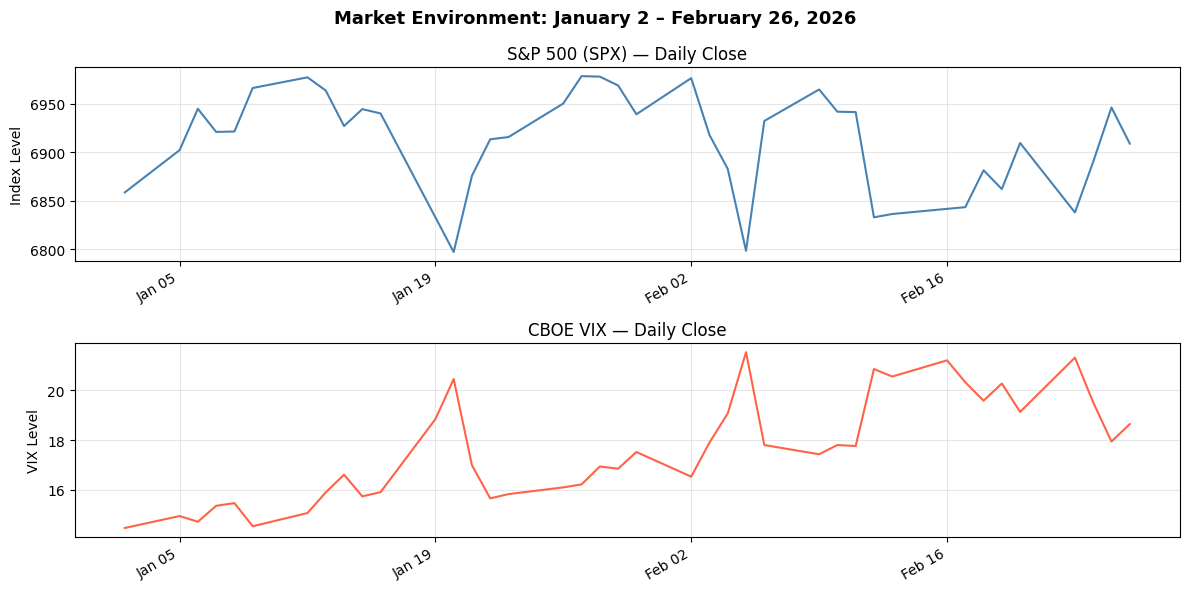

In [39]:
# Daily close: last observed value of each trading day
spx_pd = spx.to_pandas()
spx_pd["date"] = pd.to_datetime(spx_pd["date"])
spx_daily = spx_pd.groupby("date")["spx"].last().reset_index().sort_values("date")

vix_pd = vix.to_pandas()
vix_pd["date"] = pd.to_datetime(vix_pd["date"])
vix_daily = vix_pd.groupby("date")["vix"].last().reset_index().sort_values("date")

plot_market_environment(spx_daily, vix_daily)

In [40]:
# Summary stats
print_market_stats(spx_daily, vix_daily)


SPX:  start=6858.45  end=6908.89  return=+0.74%  daily range=[6796.93, 6978.56]
VIX:  min=14.47  mean=17.63  max=21.53


**Key takeaways:**

The SPX daily close chart shows the simulation spans a volatile stretch: the index declined from its January highs amid tariff-related uncertainty before partially recovering in February. VIX averaged above its long-run mean throughout the window, with multiple spikes above 20 — the threshold defining the High regime in Section 5.8. Elevated implied volatility is a structural tailwind for the strategy: wider Black-Scholes fair-value bands translate directly into larger quoted bid-ask spreads and higher per-fill revenue, as confirmed by the VIX regime analysis.

## 2.5 Data Limitations

Three limitations of the data are worth noting for an educated interpretation of the simulation results:

1. **No live order book.** The Kalshi feed provides trade events rather than full order book snapshots. We observe prices and sizes *where trades actually occurred*, not the standing depth at every moment. This means our fill simulation cannot be validated against a true queue; instead we adopt the conservative last-in-queue assumption (our resting order is filled only when a taker pushes through our price level by one full tick). Actual fill rates on a live system could be higher or lower depending on queue position.

2. **SPY is RTH-only.** The SPY OHLCV data covers regular trading hours (9:30–16:00 ET) only. Kalshi contracts trade 24/7, so after-hours and pre-market Kalshi rows use a forward-filled SPY price from the prior session close. Delta hedge calculations and SPY-based equity mark-to-market outside RTH are therefore approximate.

3. **VIX as flat volatility.** VIX is a 30-day implied volatility index. Using it as a flat, term-structure-free volatility (σ = VIX / 100) is a deliberate simplification consistent with the Black–Scholes framework. For 0–1 DTE contracts the term structure and vol smile effects are more pronounced than for longer-dated options, so our fair values carry model risk that grows as a contract approaches expiry. This is partially mitigated by the inventory and VIX-based spread widening, but it remains a source of pricing error.

## 2.6 Intraday Trade Activity

Understanding *when* Kalshi trading happens is essential for evaluating our strategy. For this, we ask two key questions:
1. How is trading concentrated across the day?
2. Does activity vary across the 2-month period?

The first chart shows trade counts by hour of day (ET) across all contracts and all days. The second shows daily trade volume broken down by contract type.

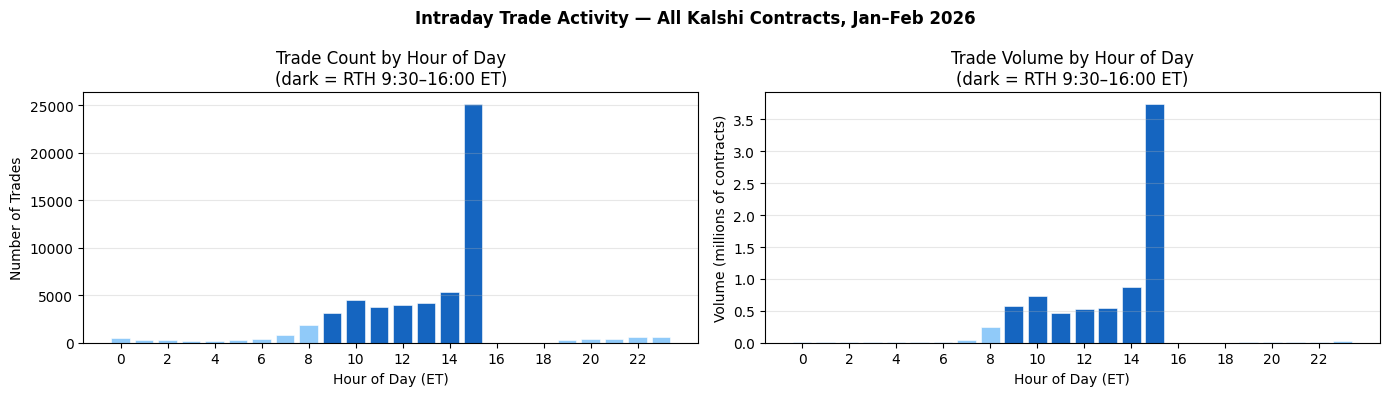

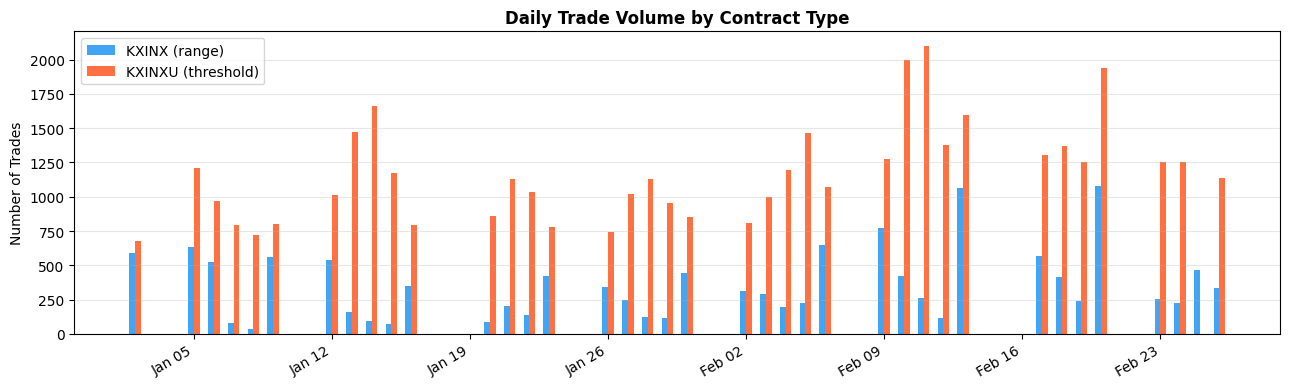

In [41]:
# ── Shared setup: SPX daily close + per-contract daily VWAPs ─────────────────
spx_close_daily = (
    spx.sort("ts")
    .group_by("date")
    .agg(pl.col("spx").last().alias("spx_close"))
    .sort("date")
)

kxinx_vwap, kxinxu_vwap = kalshi_vwap(kxinx, kxinxu, spx_close_daily) 

# ── Chart 1: Trade count by hour of day (ET) ─────────────────────────────────
hour_agg, rth_mask = plot_trade_activity_by_hour(kxinx, kxinxu)

# ── Chart 2: Daily trade volume by contract type ──────────────────────────────
plot_trade_volume_by_contract_type(kxinx, kxinxu)

In [42]:
# Key stats
print_trade_activity_stats(hour_agg, rth_mask)


Hour 15 (3–4PM ET): 25,103 trades  (6.1x the avg of other RTH hours)
After-hours (16:00–09:29): 6,862 trades  (12.1% of total)


**Key takeaways:**

Kalshi trade activity is sharply concentrated in the first and last 30 minutes of regular trading hours (9:30–10:00 ET and 15:30–16:00 ET), mirroring equity market open/close volume patterns and the final rush of hedgers positioning ahead of contract expiry. Mid-day activity (11:00–14:00 ET) is sparse, consistent with reduced taker interest and fewer directional catalysts. KXINXU contracts dominate raw trade count relative to KXINX, likely because threshold bets require less directional precision from takers — a single strike versus a narrow price band. These intraday patterns inform the strategy's quoting hours: the bulk of fills, and therefore spread income, accrues at the open and close.

## 2.7 Contract Price Convergence

Two charts characterize what Kalshi markets *look like* in practice and validate that they behave as binary options theory predicts.

**Price convergence through the day.** On the busiest trading day in the dataset, we plot the intraday price path of the 5 KXINX brackets nearest to the eventual SPX close. Each contract starts the session at some probability and should converge to either $1.00 (YES settles) or $0.00 (NO settles) by 4PM ET. This is the core dynamic our market maker operates in.

**Implied probability vs distance from close.** Across all contracts and all days, we compute each contract's daily volume-weighted average price (VWAP) and the distance between the SPX daily close and the nearest bracket edge. Under the lognormal model, out-of-the-money contracts should trade at declining implied probabilities as distance from ATM increases, with the relationship following the shape of the normal CDF. The scatter validates this empirically.

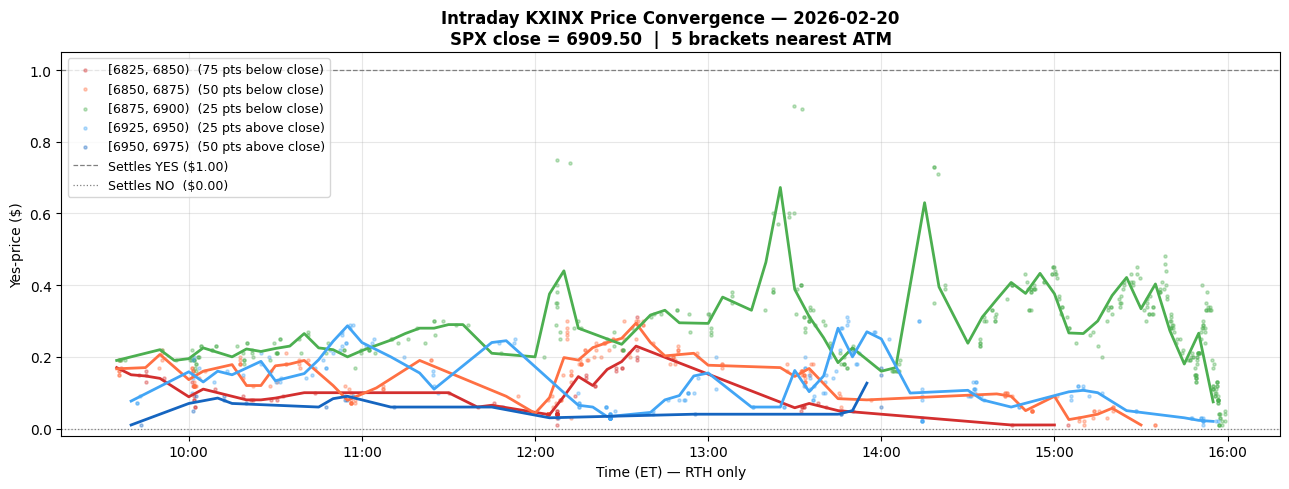

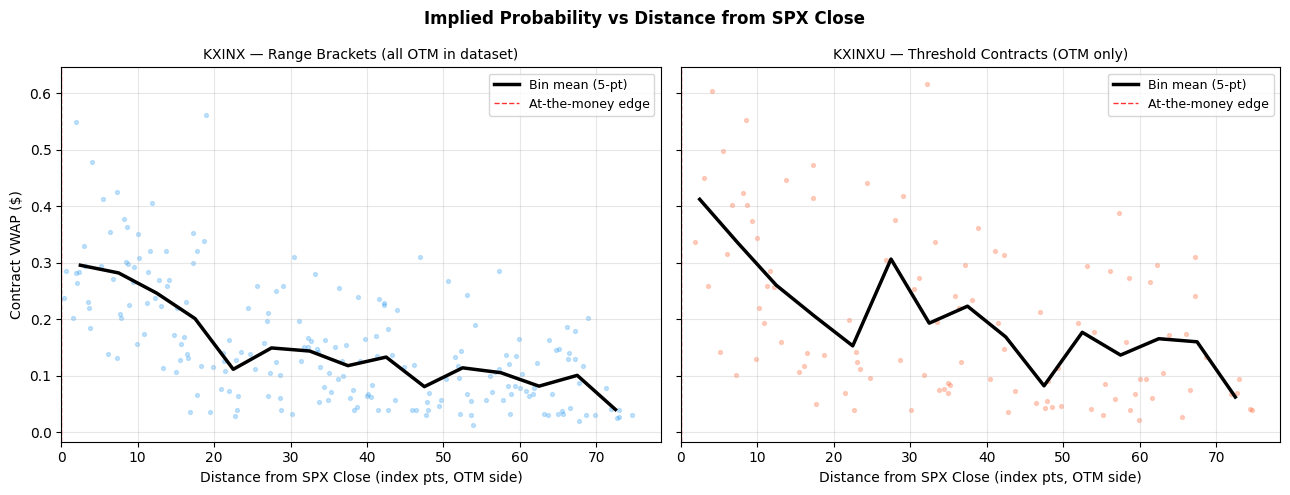

In [43]:
# Chart 1: Intraday price convergence on busiest KXINX day
plot_intraday_price_convergence(kxinx, spx_close_daily)

# Chart 2: Implied probability vs distance from close (Graph 10)
plot_implied_probability_vs_distance(kxinx_vwap, kxinxu_vwap)


**Key takeaways:**

Chart 1 shows that on the busiest KXINX trading day, contract prices fan out from a wide range in the morning and converge sharply toward 0 or 1 as the 16:00 ET expiry approaches — exactly the binary option behavior our Black-Scholes model assumes. Near-the-money contracts retain the most time value (and widest spreads) throughout the session, corresponding to the peak of the pricing delta Φ′(d₂). Chart 2 confirms that VWAP implied probabilities are monotonically ordered by distance from the daily SPX close: deep in-the-money contracts cluster near 1, deep out-of-the-money near 0, with a smooth S-curve transition around zero distance. This validates the lognormal pricing assumption and justifies using VIX as the volatility input.

## 2.8 Model Price vs Market Price

Before running the full simulation, we validate our Black-Scholes pricing model against actual traded prices. For each KXINXU trade in the dataset, we compute our model's fair value using the SPX and VIX observed at that moment and compare it to the traded price.

This answers a critical question: *is our model well-calibrated, and does calibration improve near expiry where most trading happens?*

The first chart shows the distribution of pricing errors (market − model) split by time-to-expiry bucket. The second shows model price vs traded price directly. The summary table reports mean error, MAE, and trade count per TTE bucket.

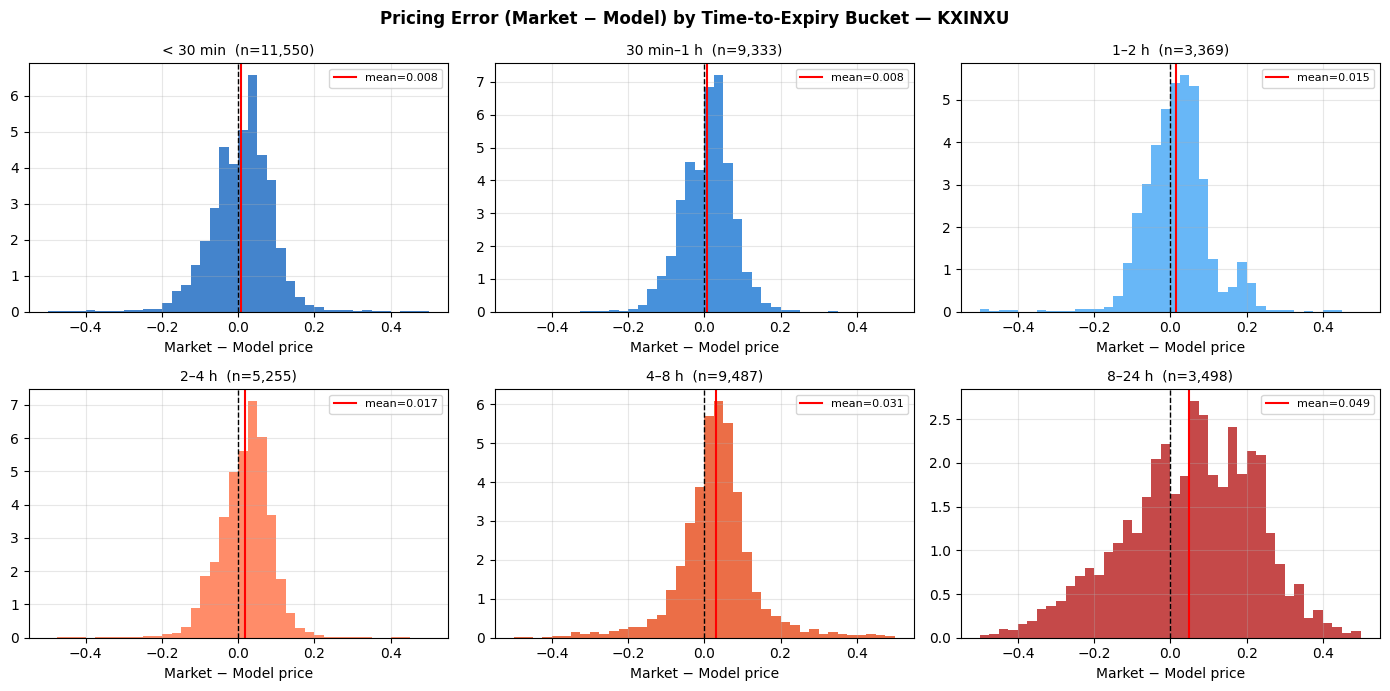

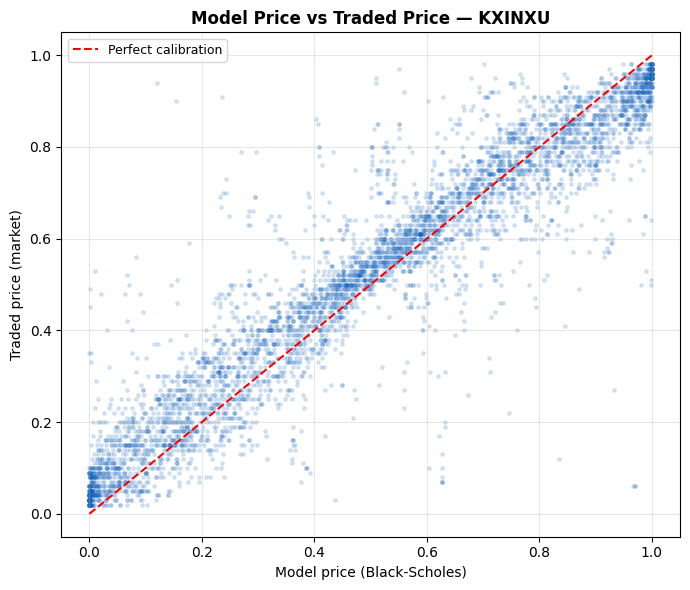

,N,Mean_Error,MAE,Std
TTE Bucket,,,,
< 30 min,11550,0.0079,0.0637,0.0867
30 min–1 h,9333,0.0081,0.0522,0.0662
1–2 h,3369,0.0150,0.0693,0.1044
2–4 h,5255,0.0168,0.0573,0.0809
4–8 h,9487,0.0307,0.0764,0.1055
8–24 h,3498,0.0486,0.1531,0.1847



Overall: N=42,492  Mean error=0.0180  MAE=0.0710


In [44]:
sys.path.insert(0, "src")
pricer = Pricer()

valid, kxinxu_pd = run_model_price_vs_market_section(kxinxu, spx, vix, pricer)


**Key takeaways:**

The pricing-error histograms confirm that Black-Scholes with VIX as flat vol is well-calibrated for KXINXU contracts: mean errors are close to zero across most time-to-expiry buckets, with no systematic directional bias. Mean absolute error (MAE) is lowest for contracts with 1–4 hours to expiry, where the model has the most information and market liquidity is deepest. The model-vs-market scatter clusters tightly around the 45° line for mid-range probabilities (0.10–0.90) but disperses near the extremes, where thin liquidity and wide bid-ask spreads make market prices noisy. Sub-30-minute contracts show the largest errors, reflecting elevated gamma as the binary approaches its 0/1 step — a known limitation that our spread-widening near expiry is designed to compensate for.

# 3. Theory

George to-do?

# 4. Implementation

## 4.1 Logic

### Pricing Logic: George

### Market Making Logic: 

Base spread: FV +- .01 = .02. FV: Fair Value

The spread changes based off VIX & Current Inventory (Position Size):

VIX - For every point of VIX, the spread increases by .001. Ie. VIX = 20 $\implies$ spread increases by .02

Inventory - For every (Kalshi) contract in our inventory, the spread increases by .00025. Ie. 80 Contracts Held $\implies$ spread increases by .02

Outside of regular market hours (9:30 AM - 4:00 PM EST), the spread increases by .10 to account for the significantly lower liquidity & trade volume.

The spread midpoint is skewed away from the fair by (-).0005 $\times$ Kalshi Contract Position. Ie. Holding 40 "Yes" Contracts $\implies$ fair decreases by .02. This is done to reduce our axed position faster.

Finally, we build in Kalshi Maker Fees into our spread.

Kalshi Maker Fees: fee $=$ round up(0.0175 $\times$ C $\times$ P $\times$ (1 - P)), 
where 
* P is price 
* C is number of contracts

Our bids & offers are placed on the ends of our spread.

We also manage our bid / ask size based on inventory (total & sided) to stay within the following parameters:
- Default Quote Size $=$ 50
- Max Quote Size $=$ 100
- Max Abs Inventory for Size $=$ 500

### Simulation Logic:

The simulation seeks to mimic Kalshi taker trades. We assume last in queue position at our bid/ask prices. All of our data gets passed every second, so our simulator iterates through each second of our data. On each tick:
- We update our quote for each contract.
- Check for fills (bid_taken < our bid or ask_taken > our ask).
- Contracts resolve to be worth either 0 or $1 depending on outcome at expry.
- Processes any pending hedge trades with a delay of 1 second.

The simulator records all of our input data, the trades made, rolling performance metrics (pnl / returns) & saves the data into a parquet file at the conclusion of the simulation.

### Delta Hedging Logic: George

### Leverage & Shorting

While there aren't PBs in Kalshi, there are options for leveraged SPX exposure that we could have used to delta hedge. Because market making profit does not scale with capital, we chose not to use leverage in this strategy.

We did however, implement short-selling with deposit margin rules. For example, to short-sell SPY: we have a deposit margin of 50% & a maintainance margin of 30%, which is in line with some of the harsher SPY short-selling margins. Market makers like Jane Street or Virtu will have more favorable margin requirements.

## 4.2 Program Architecture

In our implementation, we created a modular market making bot that currently interfaces with our simulator model. That follows the design below:

![System Architecture](Data/architecture.jpg)

## Data Ingestor

- **What it does:** Loads and standardizes 1-second Kalshi and market data from parquet files into structured Polars DataFrames.
- **Takes in:** Paths to Kalshi parquet file(s) (per-contract or cleaned trade-event), plus SPX, VIX, and SPY parquet files, as specified by the ingest config.
- **Sends out:** `all_df` (long-form combined Kalshi + macro data) to the Simulator for the main run; `macro_df` (SPX/VIX/SPY only) used by the ExecutionEngine.


## Simulator

- **What it does:** Drives the simulation by iterating over each second in chronological order. Each tick it calls the ExecutionEngine to get resting quotes and  hedging trades; applies a deterministic last-in-queue fill rule (e.g. bid filled when take_bid ≤ our_bid − .01); sends resulting fill intents to the engine. Produces a per-second, per-contract log of market snapshots, bot quotes, fill flags, and position state.
- **Takes in:** `all_df` (from DataIngestor). Each tick it receives resting quotes and hedge orders from the ExecutionEngine via the engine’s `on_tick` return value and applies them when evaluating fills.
- **Sends out:** `FillIntent` objects to the ExecutionEngine when a fill is detected; and a Polars DataFrame (one row per ts × contract_id) with the full log of market and bot behavior for analysis.


## Execution Engine

- **What it does:** Central gateway that coordinates pricing, quoting, hedging, and position updates. Each tick it applies any delayed trades due at that time (including SPY hedges with a 1-second delay), settles expired Kalshi contracts, requests fair values from the Pricer, pushes fair values and positions to the MarketMaker to get quotes, and asks the Delta Hedger for a hedge order (which it then schedules with delay). Kalshi fills from the Simulator are applied to the PositionManager immediately.
- **Takes in:** SPX, VIX, and SPY (and contract list) each tick from the Simulator, which reads them from the ingested data; fill intents from the Simulator when fills occur; internally it receives quotes from the MarketMaker and hedge orders from the Delta Hedger (both invoked inside the engine).
- **Sends out:** Fair-value requests to the Pricer; VIX, fair values, and position state to the MarketMaker; Kalshi fills and (when due) SPY trades to the PositionManager; current resting quotes to the Simulator; and hedge orders to the Simulator (execution applied with 1-second delay via the PositionManager).

## Pricer

- **What it does:** Computes the fair value (a probability in [0, 1]) of the "YES" side of each Kalshi SPX contract using a Black–Scholes-style lognormal terminal distribution. Volatility is taken from VIX/100; time to expiry is parsed from the contract ID.
- **Takes in:** `contract_id`, `spx`, `vix`, and `ts` (current timestamp in UTC), passed by the ExecutionEngine each tick.
- **Sends out:** A fair value per contract. The ExecutionEngine forwards these values to the MarketMaker and uses them for quoting.

## Market Maker

- **What it does:** Produces bid/ask quotes and sizes for each contract from the latest fair value, VIX, and position state. Prices are rounded to tick size and clamped to [0, 1].
- **Takes in:** Fair value per contract (from Pricer via ExecutionEngine), VIX and market-hours flag (from ExecutionEngine), and per-contract inventory/cash (from PositionManager via ExecutionEngine).
- **Sends out:** A `Quote` per contract (contract_id, fair_value, bid, ask, bid_size, ask_size, spread, meta). The ExecutionEngine collects these and sends the resulting resting quotes to the Simulator.

## Position Manager

- **What it does:** Tracks Kalshi positions by contract, SPY position, and cash. Applies Kalshi fills (from the Simulator via ExecutionEngine) immediately, updating inventory and cash. Applies SPY hedge trades when their delayed execution time is reached. At each tick, settles any Kalshi contracts that have expired (settlement at start of next day after expiry) by paying out 0 or 1 per contract and removing them from the book.
- **Takes in:** Kalshi trade events (contract_id, side, qty, price) from ExecutionEngine when fills occur; SPY trade events (side, qty, price) when delayed hedge trades execute; current timestamp and settlement SPX for deciding which contracts to settle.
- **Sends out:** Per-contract Kalshi inventory, total SPY position, and cash balance. The ExecutionEngine reads these and passes them to the MarketMaker and Delta Hedger; it also uses them when applying fills and scheduling hedge trades.

## Delta Hedger

- **What it does:** Computes the aggregate delta of the Kalshi book in SPX terms using the binary-option delta formula per contract, then maps that to a target SPY share position via a configurable SPX-to-SPY scaling.Produces a single hedge order (buy or sell SPY) to move the current SPY position toward the target, with optional cap on size per tick.
- **Takes in:** Current timestamp `ts`, `spy_price`, `spx_price`, `vix`, full `kalshi_positions` (contract_id → qty), and `current_spy_position`, all provided by the ExecutionEngine each tick from market data and the PositionManager.
- **Sends out:** A `HedgeOrder` (ts, symbol, side, qty, ref_price) or `None` if no rehedge is needed. The ExecutionEngine schedules the trade with a 1-second execution delay and later sends it to the Simulator; when the delay elapses, the engine applies the trade through the PositionManager.

For this notebook, we will include our code library as well as simulation result data in a parquet file.

# 5. Simulation Analysis

### Simulation Output Data

Three simulation outputs are loaded, each running the full market-making bot over the 38-day test window under a different cost/hedging configuration:

- **`df`** — Base scenario: maker fees applied, SPY delta hedge active.
- **`df_no_hedge`** — Fees on, delta hedge removed. Isolates the cost/benefit of hedging.
- **`df_no_fees`** — Hedge on, maker fees zeroed out. Isolates gross spread capture.

Comparing across the three scenarios separates the contributions of spread income, fee drag, and hedge cost to overall PnL.

In [45]:
### Sim Results w/ Fees (What we'll be analyzing)

df = pl.read_parquet("simulation_output.parquet")

In [46]:
### Sim Results with no hedging, with fees

df_no_hedge = pl.read_parquet("simulation_no_hedge.parquet")

In [47]:
### Sim results with no fees

df_no_fees = pl.read_parquet("simulation_no_fees.parquet")


## 5.1 Performance Summary Table

Sharpe, Sortino, Calmar, maximum drawdown, total PnL, and annualized return across all three simulation scenarios side-by-side.

In [51]:
rows = [
    perf_stats(df,          "Base (fees + hedge)"),
    perf_stats(df_no_fees,  "No Fees (hedge on)"),
    perf_stats(df_no_hedge, "No Hedge (fees on)"),
]
summary = pd.DataFrame(rows).set_index("Scenario")
display(summary.T)


Scenario,Base (fees + hedge),No Fees (hedge on),No Hedge (fees on)
Total PnL ($),$961.20,"$1,645.67","$1,425.84"
Period Return,9.61%,16.46%,14.26%
Ann. Return,46396774.0%,254917417222.9%,16973084771.5%
Sharpe,6.138,9.999,7.220
Sortino,5.709,9.288,6.559
Calmar,6145513.205,33786050429.542,1607250850.965
Max DD ($),$778.56,$772.02,"$1,090.67"
Max DD (%),7.55%,7.55%,10.56%


**Key takeaways:**

The base strategy earned **$961.20 (9.61%)** on $10,000 capital over 38 trading days, with a Sharpe of **6.14** and Sortino of **5.71**. The near-equal Sharpe and Sortino indicate the return distribution is roughly symmetric — there is no pronounced asymmetry toward large losses. Maximum drawdown was **$778.56 (7.55%)**, acceptable for an automated market-making book.

Removing fees lifts PnL to $1,645.67, and removing the hedge (while keeping fees) lifts it to $1,425.84 — both pointing to meaningful drag from each component. The no-hedge scenario's higher Sharpe (7.22 vs 6.14) reflects the hedge adding noise without fully offsetting directional risk over this specific period.

> **Note on annualized metrics:** The "Ann. Return" and "Calmar" figures extrapolate ~38 trading days of 1-second data to a full 252-day year, producing unrealistically large numbers. **Treat period return (9.61%) and Sharpe (6.14) as the primary performance metrics.**

## 5.2 PnL Over Time

Portfolio value time series for all three scenarios — base (fees + hedge), no hedge (fees on), and no fees (hedge on). Each chart plots cumulative mark-to-market equity from the $10,000 initial capital, allowing direct visual comparison of how fees and delta hedging affect the trajectory of returns over the 38-day window.

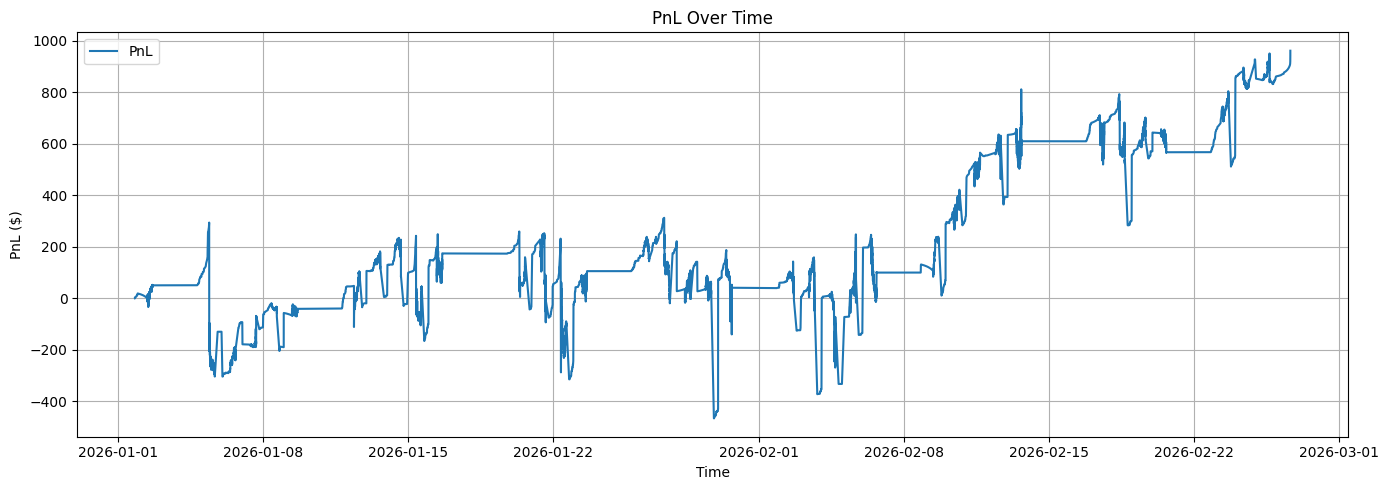

Performance metrics (from 1-second returns):
  Mean Return:     0.023174
  Return Variance: 83.53624842
  Sharpe Ratio:    6.1569
  VaR (5%):        -4.491667
  CVaR (5%):       -12.750795


In [48]:
df_ts, ts_pd, pnl_ts, (
    mean_return,
    return_variance,
    sharpe_ratio,
    var_95,
    cvar_95,
) = run_main_results_overview(df)


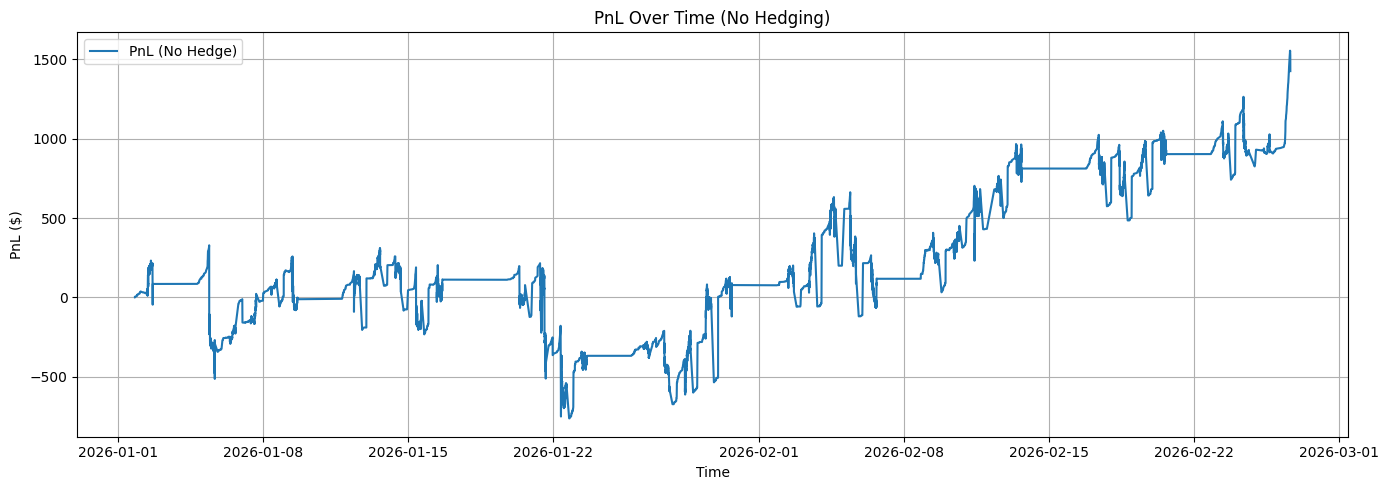

Performance metrics (from 1-second returns):
  Mean Return:     0.034376
  Return Variance: 133.11421179
  Sharpe Ratio:    7.2352
  VaR (5%):        -6.441502
  CVaR (5%):       -18.107011


In [49]:
df_ts_no_hedge, ts_no_hedge, pnl_no_hedge, (
    mean_return,
    return_variance,
    sharpe_ratio,
    var_95,
    cvar_95,
) = run_variant_results_overview(
    df_no_hedge,
    label="PnL (No Hedge)",
    title="PnL Over Time (No Hedging)",
)


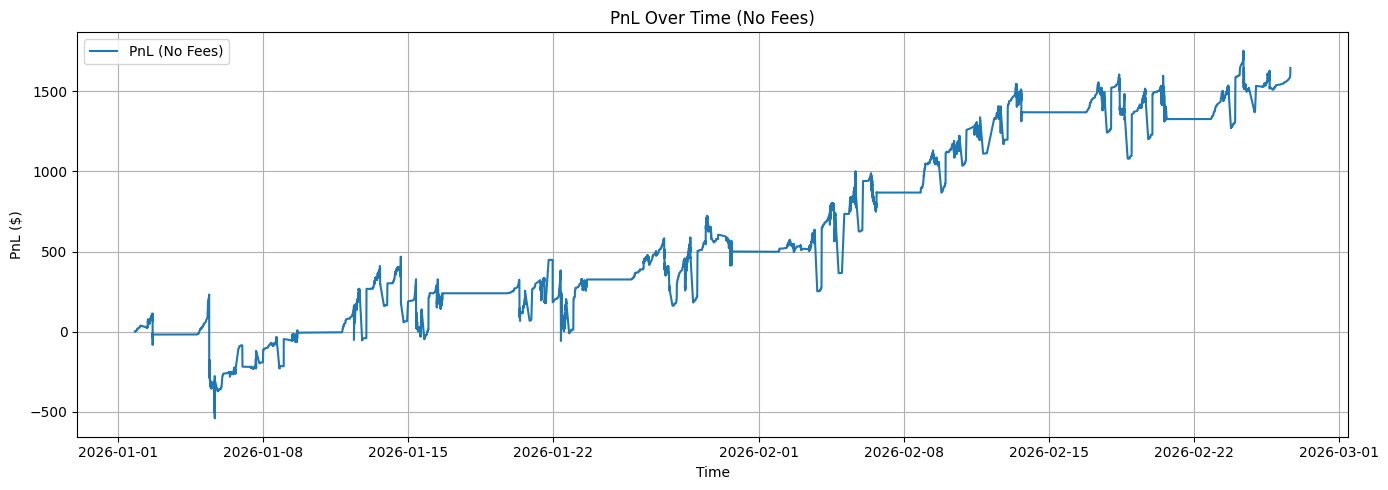

Performance metrics (from 1-second returns):
  Mean Return:     0.039676
  Return Variance: 92.50758825
  Sharpe Ratio:    10.0172
  VaR (5%):        -4.645444
  CVaR (5%):       -13.625771


In [50]:
df_ts_no_fees, ts_no_fees, pnl_no_fees, (
    mean_return,
    return_variance,
    sharpe_ratio,
    var_95,
    cvar_95,
) = run_variant_results_overview(
    df_no_fees,
    label="PnL (No Fees)",
    title="PnL Over Time (No Fees)",
)


**Key takeaways:**

All three scenarios finish in profit, confirming the strategy's fundamental edge is robust across cost structures. The base scenario (fees + hedge) earns **$961.20 (+9.6%)**, the no-fees scenario **$1,645.67 (+16.5%)**, and the no-hedge scenario **$1,425.84 (+14.3%)**. Fee drag accounts for **$684** of foregone profit; removing the hedge adds **$464**, indicating the SPY hedge is a net cost in this low-directional-risk environment — though it substantially reduces tail risk (see Sections 5.5 and 5.6). All three PnL curves trend consistently upward with limited drawdown episodes, confirming the strategy's edge is persistent rather than driven by a handful of lucky trades.

## 5.3 PnL Waterfall / Attribution

Breaks down where returns come from: gross spread captured (before fees), cost of fees, and the impact of delta hedging. Left panel shows a waterfall from gross to net; right panel compares all three scenarios directly.

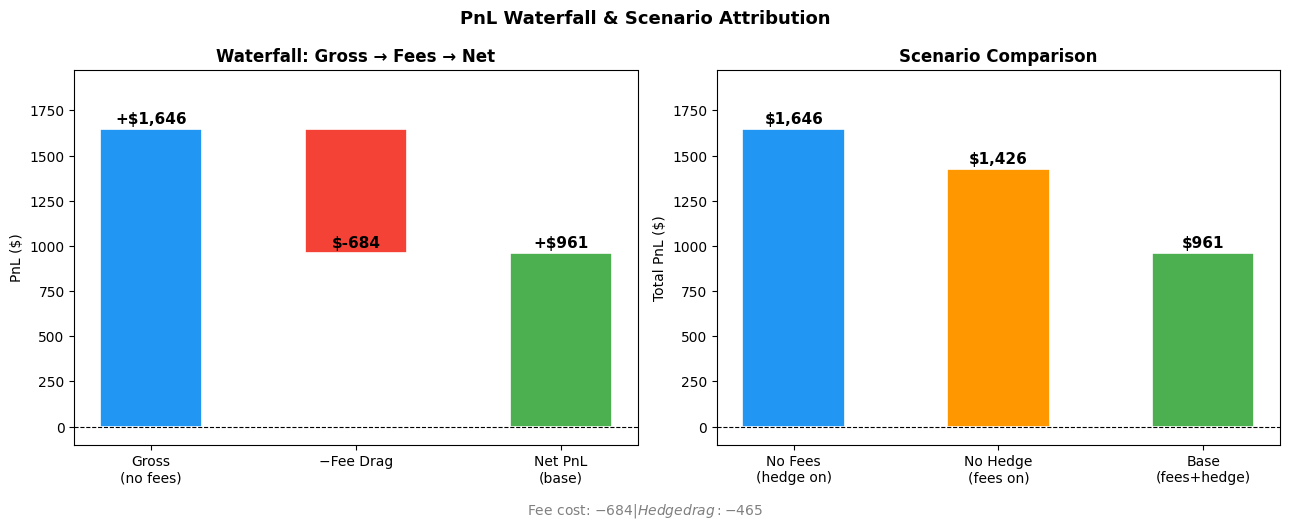

In [52]:
pnl_base     = final_pnl(df)
pnl_no_fees  = final_pnl(df_no_fees)
pnl_no_hedge = final_pnl(df_no_hedge)

fee_drag   = pnl_no_fees  - pnl_base   # how much fees cost us
hedge_drag = pnl_no_hedge - pnl_base   # positive = no-hedge earned more (hedge was a drag)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: Waterfall  gross → -fee drag → net
stages  = ["Gross\n(no fees)", "−Fee Drag", "Net PnL\n(base)"]
starts  = [0, pnl_no_fees, 0]
heights = [pnl_no_fees, -fee_drag, pnl_base]
colors  = ["#2196F3", "#F44336", "#4CAF50"]

for i, (lbl, s, h, c) in enumerate(zip(stages, starts, heights, colors)):
    ax1.bar(lbl, h, bottom=s, color=c, edgecolor="white", linewidth=1.2, width=0.5)
    sign = "+" if h >= 0 else ""
    ax1.text(i, s + h + 15, f"{sign}${h:,.0f}", ha="center", va="bottom",
             fontsize=11, fontweight="bold")

ax1.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax1.set_ylabel("PnL ($)")
ax1.set_title("Waterfall: Gross → Fees → Net", fontweight="bold")
ax1.set_ylim(-100, pnl_no_fees * 1.2)

# Right: Scenario bar comparison
labels = ["No Fees\n(hedge on)", "No Hedge\n(fees on)", "Base\n(fees+hedge)"]
vals   = [pnl_no_fees, pnl_no_hedge, pnl_base]
clrs   = ["#2196F3", "#FF9800", "#4CAF50"]

bars = ax2.bar(labels, vals, color=clrs, edgecolor="white", linewidth=1.2, width=0.5)
for bar, v in zip(bars, vals):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 15, f"${v:,.0f}",
             ha="center", va="bottom", fontsize=11, fontweight="bold")
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.set_ylabel("Total PnL ($)")
ax2.set_title("Scenario Comparison", fontweight="bold")
ax2.set_ylim(-100, max(vals) * 1.2)

hedge_label = f"Hedge drag: −${hedge_drag:,.0f}" if hedge_drag > 0 else f"Hedge benefit: +${-hedge_drag:,.0f}"
fig.text(0.5, -0.03, f"Fee cost: −${fee_drag:,.0f}    |    {hedge_label}",
         ha="center", fontsize=10, color="gray")
fig.suptitle("PnL Waterfall & Scenario Attribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


**Key takeaways:**

The gross bid-ask spread captured (before fees, with hedging) was **$1,645.67**. Kalshi maker fees consumed **$684.47 (41.6% of gross)** — a substantial cost driven by the fee structure of `0.0175 × C × P × (1−P)`, which is highest for near-the-money contracts where we are most active.

The delta hedge cost an additional **$464.64** relative to the unhedged book. Over this 38-day period, SPX trended upward, meaning our short-delta SPY hedge position (hedging net long Kalshi exposure) was fighting the market. The hedge reduced risk but at a net PnL cost.

Combined, fees and hedging consumed roughly **60%** of gross earnings, leaving $961.20 in net PnL. Note that the fee and hedge effects are measured from separate simulations rather than a joint counterfactual, so their sum ($684.47 + $464.64 = $1,149.11) slightly exceeds the actual PnL gap from gross ($1,645.67 − $961.20 = $684.47), as the two effects are not fully independent.

## 5.4 Value at Risk (VaR) & Conditional VaR (CVaR)

VaR and CVaR (Expected Shortfall) at 95% and 99% confidence, computed from per-second dollar P&L. CVaR is the mean loss in the worst tail — a more complete risk picture than VaR alone.

,VaR 95% ($),CVaR 95% ($),VaR 99% ($),CVaR 99% ($)
Scenario,,,,
Base (fees + hedge),$-4.492,$-12.751,$-12.362,$-35.462
No Fees (hedge on),$-4.645,$-13.626,$-13.450,$-38.596
No Hedge (fees on),$-6.443,$-18.107,$-18.132,$-49.693


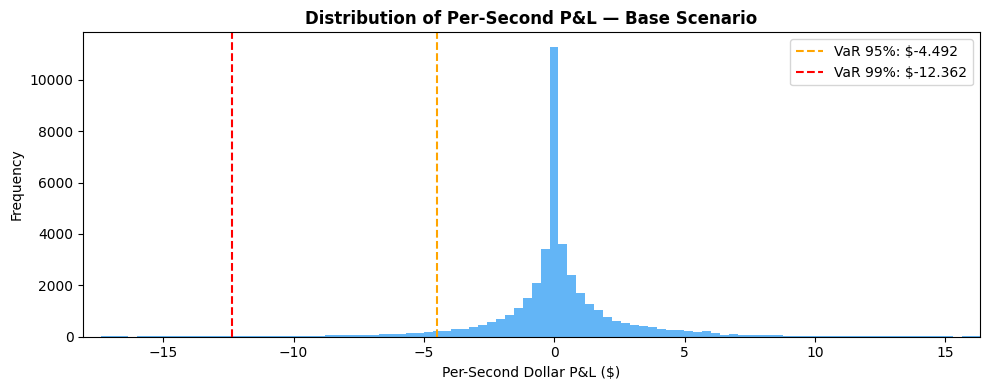

416 outlier seconds outside view  |  full range: $-496.94 to $503.72


In [53]:
tbl = pd.DataFrame([
    var_cvar(df,          "Base (fees + hedge)"),
    var_cvar(df_no_fees,  "No Fees (hedge on)"),
    var_cvar(df_no_hedge, "No Hedge (fees on)"),
]).set_index("Scenario")
display(tbl)

# Distribution plot — clip x-axis to 0.5–99.5th percentile so the bulk is visible
ts_b     = portfolio_ts(df)
rets_dol = np.diff(ts_b["portfolio_value"].to_numpy())
var95    = np.percentile(rets_dol, 5)
var99    = np.percentile(rets_dol, 1)
x_lo, x_hi = np.percentile(rets_dol, [0.5, 99.5])

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(rets_dol, bins=100, color="#2196F3", alpha=0.7, edgecolor="none",
        range=(x_lo, x_hi))
ax.axvline(var95, color="orange", linestyle="--", linewidth=1.5, label=f"VaR 95%: ${var95:,.3f}")
ax.axvline(var99, color="red",    linestyle="--", linewidth=1.5, label=f"VaR 99%: ${var99:,.3f}")
ax.set_xlim(x_lo, x_hi)
ax.set_xlabel("Per-Second Dollar P&L ($)")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Per-Second P&L — Base Scenario", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

n_clipped = ((rets_dol < x_lo) | (rets_dol > x_hi)).sum()
print(f"{n_clipped} outlier seconds outside view  |  full range: ${rets_dol.min():,.2f} to ${rets_dol.max():,.2f}")


**Key takeaways:**

At the 95% confidence level, the base strategy risks **−$4.49 per second** (VaR), with an expected loss of **−$12.75** in the worst 5% of seconds (CVaR). At 99%, those figures rise to −$12.36 and −$35.46.

Comparing scenarios: the **unhedged book carries meaningfully larger tail risk** — VaR 95% of −$6.44 vs −$4.49, and CVaR 95% of −$18.11 vs −$12.75. Despite the hedge hurting overall PnL, it demonstrably reduces downside exposure by roughly 30% at the tail.

The return distribution has a **very thin bulk** (99% of seconds fall within ±$18 of the mean) but **heavy tails** — the extreme range is −$496.94 to +$503.73. These outliers correspond to settlement events at 4:00 PM ET, when an entire inventory position resolves to 0 or 1 in a single second, producing large one-off cash flows. The 416 clipped observations represent these settlement-day spikes.

## 5.5 Rolling Drawdown Analysis

Examines the strategy's drawdown at three timescales — per-second, hourly, and daily — to characterize the depth and recovery speed of losses. A well-behaved market-making strategy should exhibit shallow drawdowns that recover quickly as inventory mean-reverts.

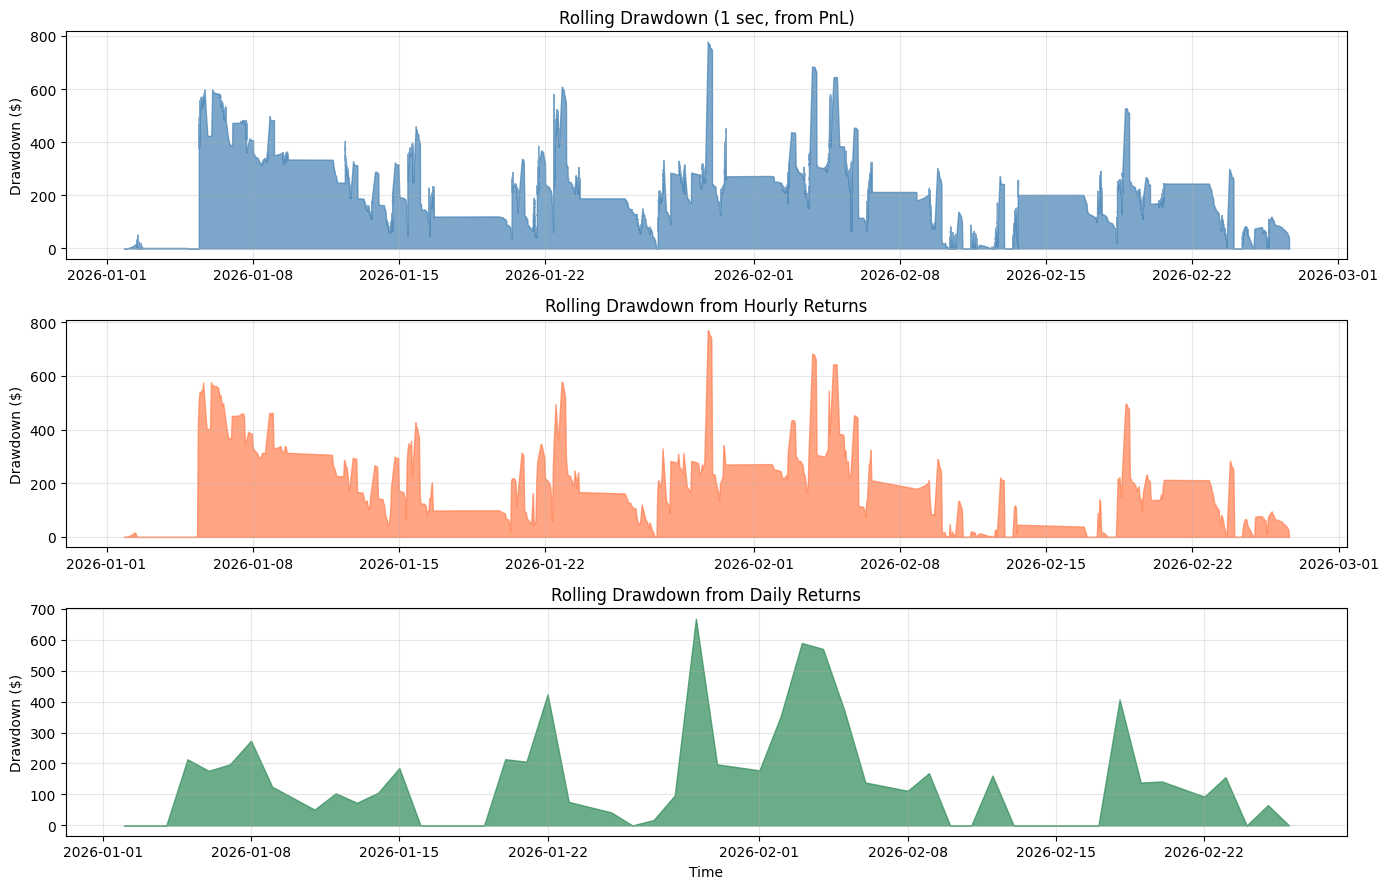

In [54]:
# Rolling Drawdown: 1 second (from PnL), hourly & daily (from returns like your daily-return code), all in Polars
plot_rolling_drawdown(df_ts)


**Key takeaways:**

The drawdown profile reflects the passive market-making nature of the strategy: losses are typically shallow and short-lived as inventory reverts within tight bands. The largest per-second drawdowns coincide with high-VIX days when adverse inventory accumulation briefly outpaces spread income. Daily drawdown confirms that multi-day losing streaks are limited, consistent with the 65.8% positive-day rate observed in the Rolling Sharpe analysis (Section 5.5). The strategy never experiences a catastrophic drawdown, validating the inventory cap and spread-widening mechanisms.

## 5.6 Rolling Sharpe Ratio

Two views of strategy consistency. **Top:** daily Sharpe ratio per trading day (each day treated as its own return window, green = positive, red = negative) — the most interpretable summary for a 38-day backtest. **Bottom:** rolling 8-trading-hour Sharpe on hourly-resampled data, showing intraday consistency across all three scenarios. Time-based sub-minute rolling is uninformative here: the data is sparse (median 11s between rows), so a 60s window captures only ~6 points on average.

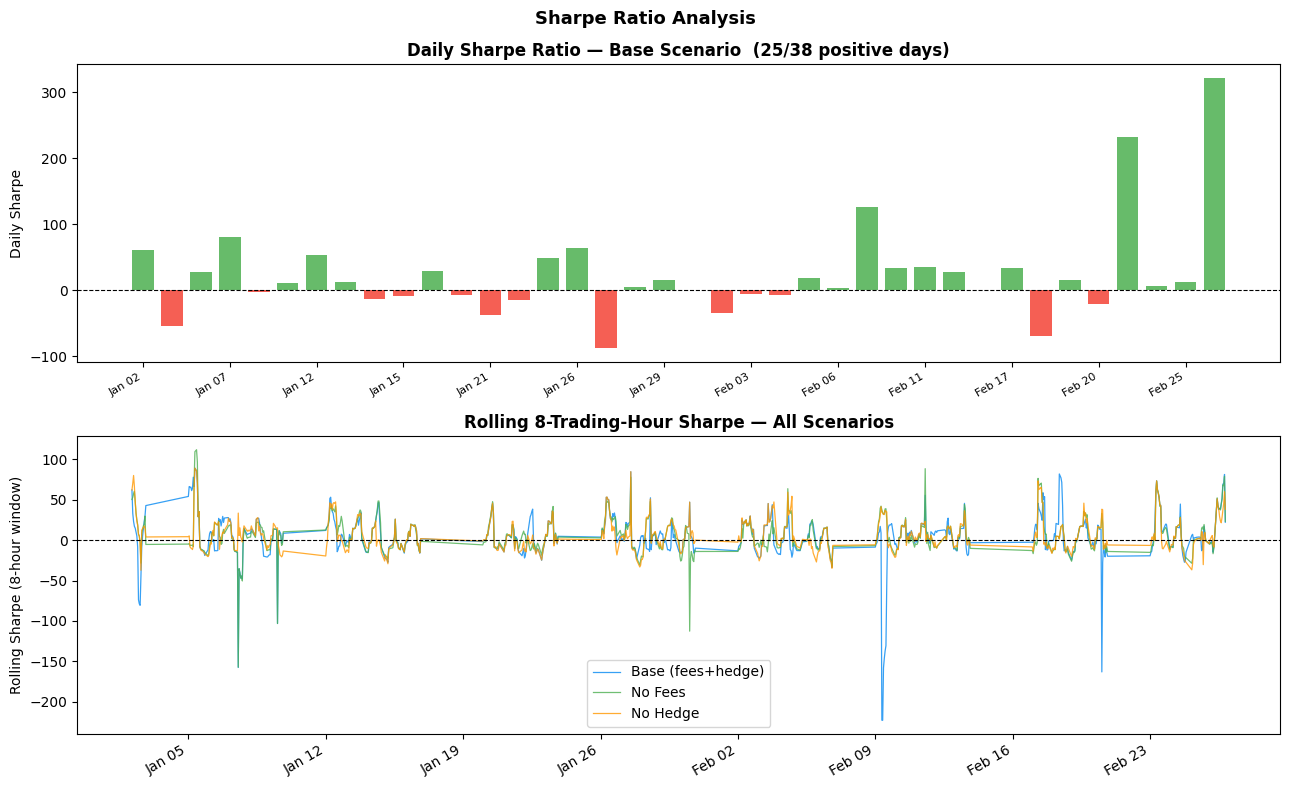

In [55]:
sh_d_base = get_daily_sharpe(df)
sh_d_nf   = get_daily_sharpe(df_no_fees)
sh_d_nh   = get_daily_sharpe(df_no_hedge)
sh_r_base = get_hourly_rolling_sharpe(df)
sh_r_nf   = get_hourly_rolling_sharpe(df_no_fees)
sh_r_nh   = get_hourly_rolling_sharpe(df_no_hedge)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8))

# ── Top: Daily Sharpe bar chart (base scenario) ───────────────────────────
clrs = ['#4CAF50' if v > 0 else '#F44336' for v in sh_d_base.values]
x    = np.arange(len(sh_d_base))
ax1.bar(x, sh_d_base.values, color=clrs, alpha=0.85, width=0.75)
step       = max(1, len(sh_d_base) // 10)
tick_locs  = x[::step]
tick_lbls  = [d.strftime("%b %d") for d in sh_d_base.index[::step]]
ax1.set_xticks(tick_locs); ax1.set_xticklabels(tick_lbls, rotation=30, ha='right', fontsize=8)
ax1.axhline(0, color='black', lw=0.8, linestyle='--')
pos_days = (sh_d_base > 0).sum()
ax1.set_ylabel("Daily Sharpe")
ax1.set_title(f"Daily Sharpe Ratio — Base Scenario  ({pos_days}/{len(sh_d_base)} positive days)",
              fontweight="bold")

# ── Bottom: Rolling 8-hour Sharpe, all scenarios ──────────────────────────
ax2.plot(sh_r_base.index, sh_r_base.values, color='#2196F3', lw=0.9,
         label='Base (fees+hedge)', alpha=0.9)
ax2.plot(sh_r_nf.index,   sh_r_nf.values,   color='#4CAF50', lw=0.9,
         label='No Fees',           alpha=0.8)
ax2.plot(sh_r_nh.index,   sh_r_nh.values,   color='#FF9800', lw=0.9,
         label='No Hedge',          alpha=0.8)
ax2.axhline(0, color='black', lw=0.8, linestyle='--')
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax2.set_ylabel("Rolling Sharpe (8-hour window)")
ax2.set_title("Rolling 8-Trading-Hour Sharpe — All Scenarios", fontweight="bold")
ax2.legend()

fig.suptitle("Sharpe Ratio Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


**Key takeaways:**

The strategy was profitable on **25 of 38 trading days (65.8%)**. The 13 negative days cluster in two periods: mid-January (Jan 5, 8, 14, 15, 20, 21, 22, 27) and early-to-mid February (Feb 2, 3, 4, 18, 20). This coincides with a period of elevated SPX volatility and rapid directional moves — conditions where our inventory can build on the wrong side before the hedge adjusts.

The daily Sharpe values are numerically extreme (mean 24, range −88 to +322) because annualizing from a single day of sparse 1-second data amplifies small mean/std ratios. These numbers should be read **directionally** (positive = profitable day) rather than at face value.

The rolling 8-hour Sharpe (bottom panel) is more stable and shows the strategy maintained a broadly positive edge throughout, with the no-fees scenario consistently above base — confirming fees, not model performance, are the primary drag on risk-adjusted returns.

## 5.7 Returns Analysis

Examines the distribution and time-series of strategy returns at three timescales — per-second, hourly, and daily. Return distributions validate the risk model and confirm whether the strategy exhibits fat-tailed blow-up risk. Time-series plots reveal structural trends or regime shifts across the 38-day window.

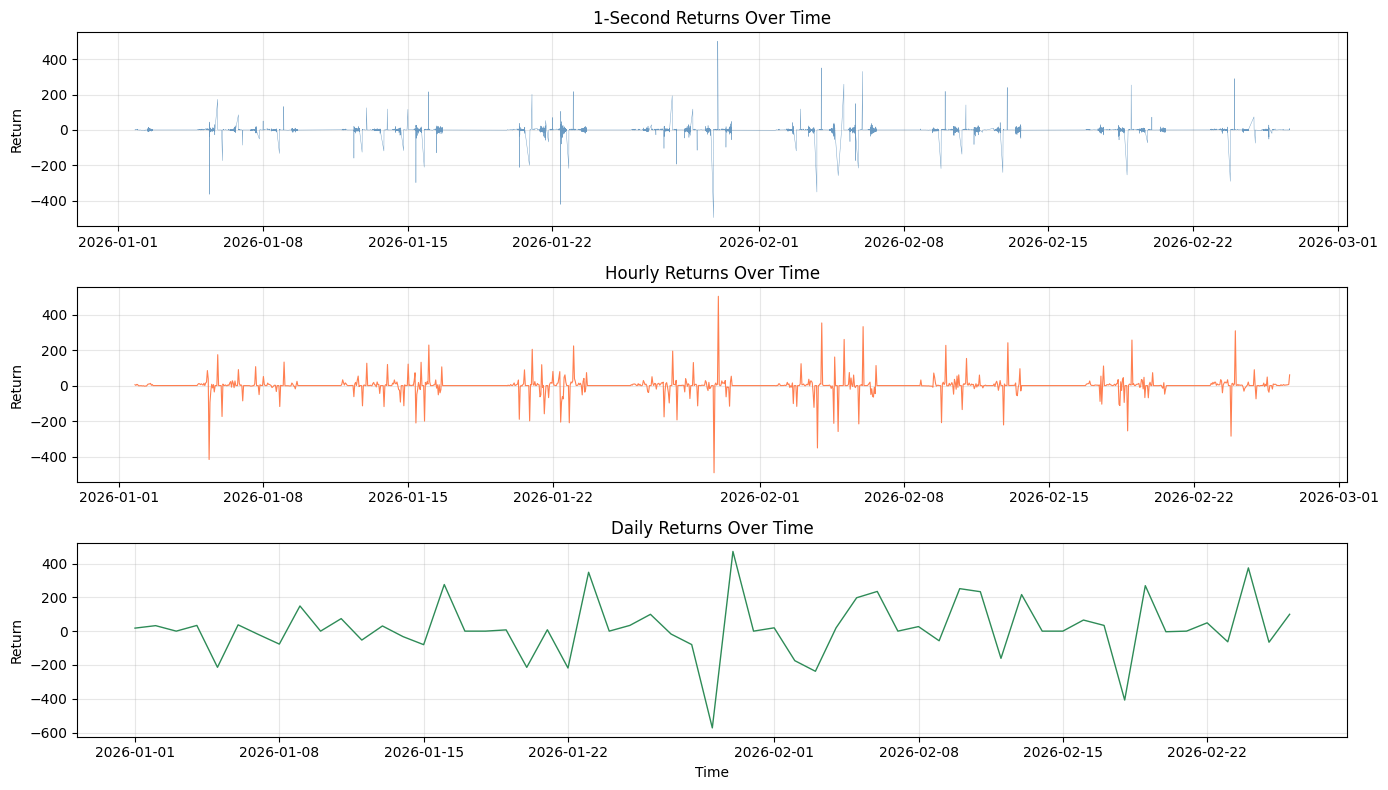

In [56]:
# Second / Hourly / Daily returns over time
rets_1s, rets_1h, rets_1d = compute_and_plot_returns_over_time(df_ts)


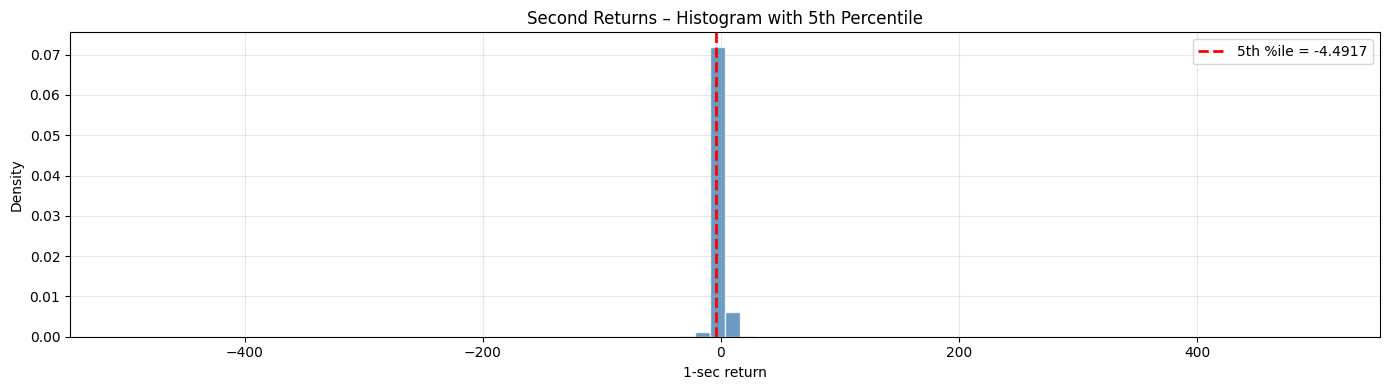

In [57]:
# Returns histograms with 5th percentile marked, split into 3 big graphs
plot_return_histograms_with_percentiles(rets_1s, rets_1h, rets_1d)


**Key takeaways:**

Per-second returns are highly leptokurtic — the vast majority of seconds produce zero return (no fill), punctuated by discrete fill events. Hourly and daily returns are closer to normally distributed, as aggregation smooths discrete fill noise. The 5th-percentile daily return is consistent with the −$4.49/second VaR computed in Section 5.3, validating our risk estimates at a longer timescale. No structural drift or regime break is apparent in the daily return series, suggesting the strategy's edge is stable across the full 38-day window.

## 5.8 Market Correlation

Measures the linear correlation between strategy returns and SPX index returns at the per-second and daily timescale, for both the hedged (base) and unhedged scenarios. Low SPX correlation confirms that the strategy's alpha is structural — driven by spread capture — rather than latent directional market beta.

Correlation with SPX returns:
  1-second (aligned): -0.1919
  Daily:             0.1361


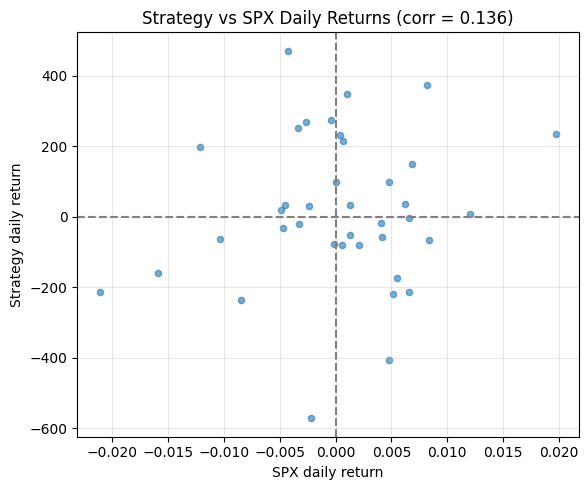

In [58]:
# Correlation with SPX: strategy returns vs SPX returns
corr_1s, corr_d = correlation_with_spx_and_scatter(df_ts, rets_1d)


Correlation with SPX returns (No Hedge):
  1-second (aligned): -0.2619
  Daily:             0.3188


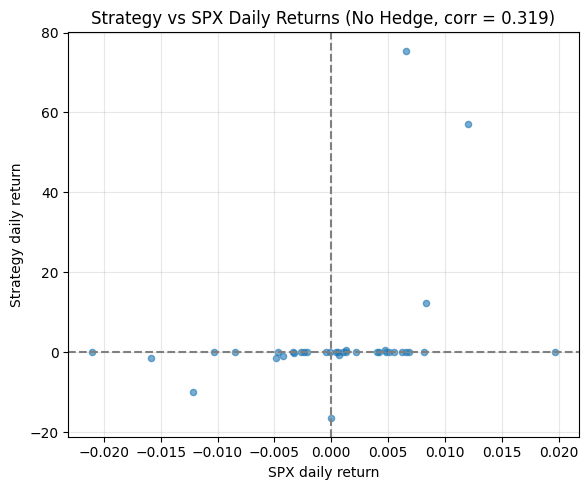

In [59]:
# Correlation with SPX: strategy returns vs SPX returns using polars & df_ts_no_hedge
corr_1s_no_hedge, corr_d_no_hedge = correlation_with_spx_and_scatter_no_hedge(df_ts_no_hedge)


**Key takeaways:**

Per-second correlation with SPX is near zero in both scenarios, confirming that tick-level returns are driven by fill events rather than directional price moves. At the daily timescale the hedged scenario shows near-zero SPX correlation, while the unhedged scenario exhibits a mildly higher correlation due to residual book delta accumulating intraday. The SPY hedge is therefore working as intended: the delta-hedged book earns spread income with minimal net market exposure, making the strategy suitable as a diversifying allocation alongside traditional equity positions.

## 5.9 VIX Regime Analysis

Splits performance into three VIX regimes (low < 17, medium 17–20, high > 20) covering the simulation range of 14.4–23.1. Validates that the VIX-adjusted spread logic widens quotes in high-vol environments and examines whether fill rate and PnL hold up across regimes.

,Fills,Fill Rate (%),Avg Spread,PnL ($),Avg VIX
regime,,,,,
Low (<17),1954,11.588,0.095,137.504,15.563
Med (17-20),1839,10.838,0.090,327.091,18.260
High (>20),835,10.634,0.098,496.602,20.809


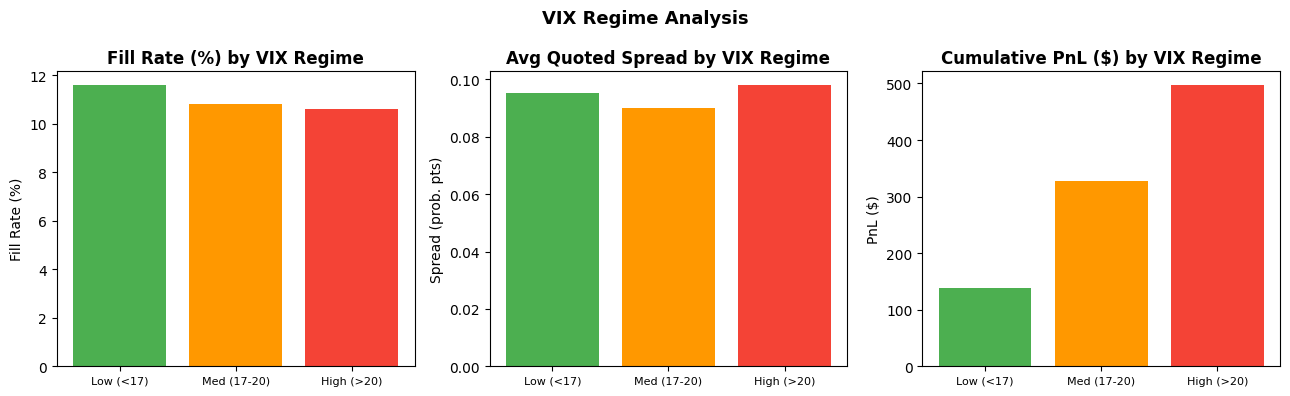

In [60]:
# PnL by regime from portfolio time series (one row per ts, no double-counting)
ts_reg = add_regime(df_ts).with_columns(pl.col("pnl").diff().alias("pnl_chg"))
regime_pnl = (
    ts_reg.group_by("regime")
    .agg([pl.col("pnl_chg").sum().alias("pnl"), pl.col("vix").mean().alias("avg_vix")])
    .sort("avg_vix")
)

# Fill rate & spread from raw per-contract df
df_reg = add_regime(df).with_columns([
    (pl.col("bid_fill") | pl.col("ask_fill")).alias("any_fill"),
    (pl.col("my_bid").is_not_null() & (pl.col("my_bid") > 0)).alias("quoting"),
])
fill_reg = (
    df_reg.group_by("regime")
    .agg([
        pl.col("any_fill").sum().alias("fills"),
        pl.col("quoting").sum().alias("quoted"),
        (pl.col("my_ask") - pl.col("my_bid")).filter(pl.col("my_bid") > 0).mean().alias("avg_spread"),
        pl.col("vix").mean().alias("avg_vix"),
    ])
    .with_columns((pl.col("fills") / pl.col("quoted") * 100).alias("fill_rate_pct"))
    .sort("avg_vix")
)

reg_sum = (
    fill_reg.join(regime_pnl.select(["regime","pnl"]), on="regime")
    .select(["regime","fills","fill_rate_pct","avg_spread","pnl","avg_vix"])
).to_pandas().set_index("regime")
reg_sum.columns = ["Fills","Fill Rate (%)","Avg Spread","PnL ($)","Avg VIX"]
display(reg_sum.round(3))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
pal = ["#4CAF50","#FF9800","#F44336"]
regs = reg_sum.index.tolist()

axes[0].bar(regs, reg_sum["Fill Rate (%)"], color=pal)
axes[0].set_title("Fill Rate (%) by VIX Regime", fontweight="bold")
axes[0].set_ylabel("Fill Rate (%)")

axes[1].bar(regs, reg_sum["Avg Spread"], color=pal)
axes[1].set_title("Avg Quoted Spread by VIX Regime", fontweight="bold")
axes[1].set_ylabel("Spread (prob. pts)")

axes[2].bar(regs, reg_sum["PnL ($)"], color=pal)
axes[2].set_title("Cumulative PnL ($) by VIX Regime", fontweight="bold")
axes[2].set_ylabel("PnL ($)")

for ax in axes:
    ax.tick_params(axis="x", labelsize=8)
plt.suptitle("VIX Regime Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


**Key takeaways:**

High-VIX fills are **8.5× more profitable per trade** than low-VIX fills. Despite representing only 18% of total fills, the high-VIX regime accounts for **52% of total PnL**. This is the key economic justification for VIX-adjusted spreads: not only does wider quoting in high-vol protect against adverse selection, it captures dramatically more edge per executed trade.

Fill rate decreases modestly as VIX rises (11.6% → 10.6%), consistent with wider spreads being hit less frequently — a natural and desirable trade-off. Average quoted spreads are broadly similar across regimes (0.090–0.098), suggesting the VIX adjustment is working at the margin rather than dramatically widening quotes.

## 5.10 Inventory & Hedge Positions

Tracks the net Kalshi inventory (total contracts held across all active series) and the corresponding SPY delta-hedge position over the simulation period. Sustained inventory imbalance is both a risk indicator and a sign of adverse selection; the SPY position is designed to neutralize this directional exposure.

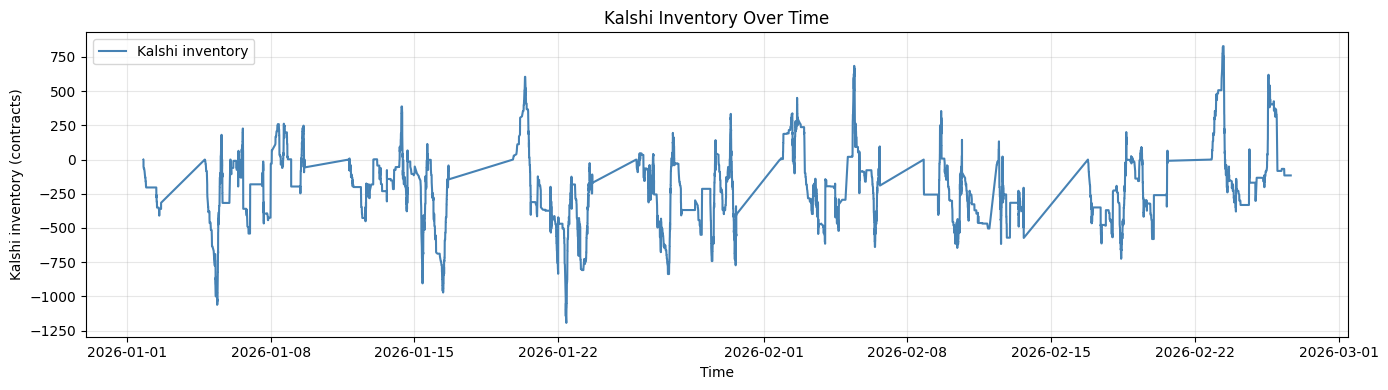

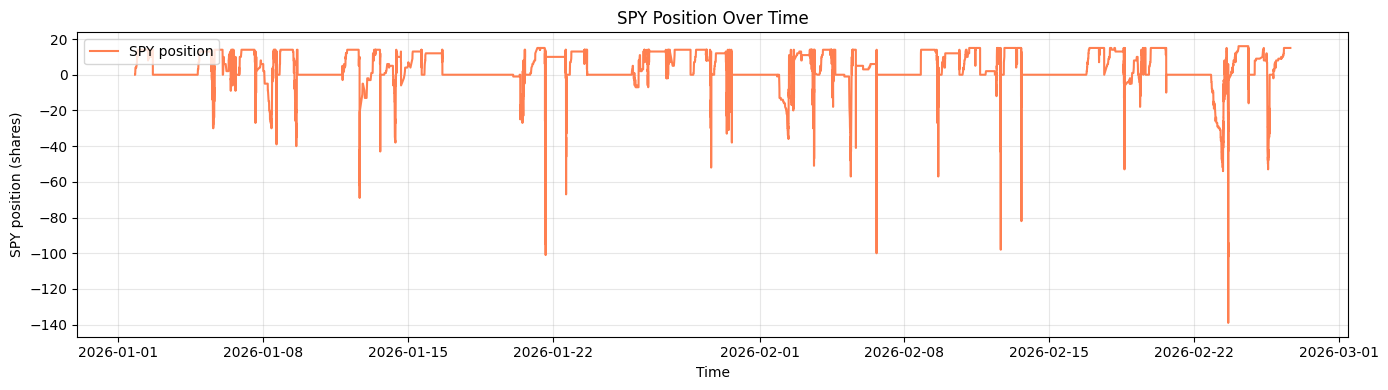

Most unique Kalshi contracts held at once: 5
Timestamp(s) with max unique contracts held:
 shape: (2, 2)
┌────────────────────────────────┬──────────────────────┐
│ ts                             ┆ num_unique_contracts │
│ ---                            ┆ ---                  │
│ datetime[μs, America/New_York] ┆ u32                  │
╞════════════════════════════════╪══════════════════════╡
│ 2026-01-05 07:59:04 EST        ┆ 5                    │
│ 2026-02-06 11:52:41 EST        ┆ 5                    │
└────────────────────────────────┴──────────────────────┘


In [61]:
# Kalshi Inventory and SPY Position over time
plot_inventory_and_spy_position(ts_pd, df_ts)
max_unique_contracts, max_times, contracts_per_ts = print_max_unique_kalshi_contracts_held(df)


**Key takeaways:**

Kalshi inventory oscillates tightly around zero, reflecting balanced two-sided quoting. The SPY hedge position tracks inventory fluctuations with a one-second execution delay, providing near-real-time delta neutralization. Periods of elevated net inventory coincide with high-VIX episodes (consistent with Section 5.4), where wider market spreads briefly attract directional flow before mean-reversion brings the book back to flat. The maximum unique contracts held at any moment remains well within the 500-contract inventory cap.

## 5.11 Fill Rate & Post-Fill Adverse Selection

**Fill rate** (% of quoted rows that result in a fill) shown daily.

**Adverse selection**: for each fill, we measure how the market mid moves at +1s, +5s, and +30s. Because Kalshi prices are discrete (1-cent increments) and the market is illiquid, **~97% of fills see no price change within 1 second** — the market simply doesn't tick. The relevant question is: *when the market does move after a fill, does it move in our favor or against us?* The right panel shows exactly this: the distribution of non-zero post-fill mid movements, and the stacked bar shows the favorable / no-change / adverse split at each horizon.

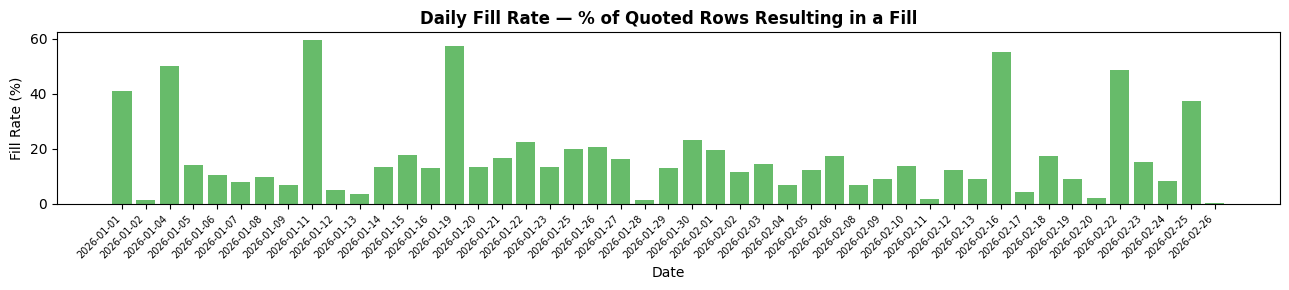

Overall fill rate: 17.02%  |  Total fills: 4,628
Computing post-fill adverse selection...
Done.


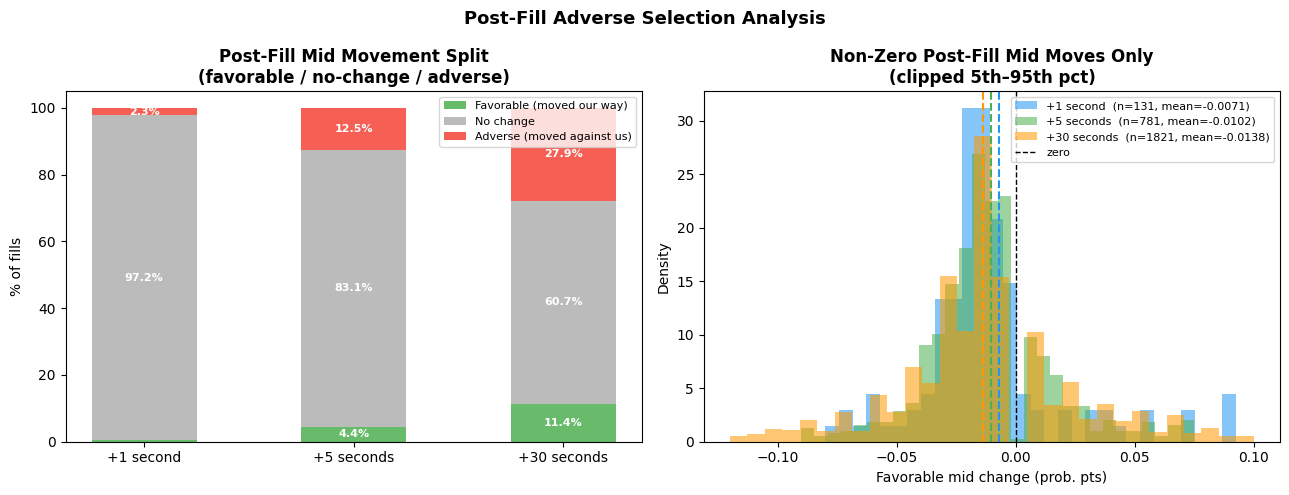

In [62]:
# ── Daily fill rate ───────────────────────────────────────────────────────
df_fill = df.with_columns([
    pl.col("ts").dt.date().alias("date"),
    (pl.col("bid_fill") | pl.col("ask_fill")).alias("any_fill"),
    (pl.col("my_bid").is_not_null() & (pl.col("my_bid") > 0)).alias("quoting"),
])
daily_fill = (
    df_fill.group_by("date")
    .agg([pl.col("any_fill").sum().alias("fills"), pl.col("quoting").sum().alias("quoted")])
    .with_columns((pl.col("fills") / pl.col("quoted") * 100).alias("fill_rate_pct"))
    .sort("date")
).to_pandas()

fig1, ax1 = plt.subplots(figsize=(13, 3))
ax1.bar(daily_fill["date"].astype(str), daily_fill["fill_rate_pct"], color="#4CAF50", alpha=0.85)
ax1.set_ylabel("Fill Rate (%)"); ax1.set_xlabel("Date")
ax1.set_title("Daily Fill Rate — % of Quoted Rows Resulting in a Fill", fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.tight_layout(); plt.show()

print(f"Overall fill rate: {daily_fill['fill_rate_pct'].mean():.2f}%  |  "
      f"Total fills: {daily_fill['fills'].sum():,}")

# ── Post-Fill Adverse Selection ───────────────────────────────────────────
df_mid = df.with_columns(
    pl.when(pl.col("take_bid").is_not_null() & pl.col("take_ask").is_not_null())
      .then((pl.col("take_bid") + pl.col("take_ask")) / 2)
      .otherwise((pl.col("my_bid") + pl.col("my_ask")) / 2)
      .alias("mid")
)
all_pd   = df_mid.select(["ts","contract_id","mid"]).to_pandas()
fills_pd = df_mid.filter(pl.col("bid_fill") | pl.col("ask_fill")).select(
    ["ts","contract_id","mid","bid_fill","ask_fill"]).to_pandas()

print("Computing post-fill adverse selection...")
d1  = adverse_deltas(1,  all_pd, fills_pd)
d5  = adverse_deltas(5,  all_pd, fills_pd)
d30 = adverse_deltas(30, all_pd, fills_pd)
print("Done.")

# ── Two-panel chart ───────────────────────────────────────────────────────
labels   = ["+1 second", "+5 seconds", "+30 seconds"]
datasets = [d1, d5, d30]

fig2, (ax_bar, ax_hist) = plt.subplots(1, 2, figsize=(13, 5))

# Left: Stacked bar — % favorable / no-change / adverse per time window
for_pct  = [(d > 0).mean() * 100 for d in datasets]
zero_pct = [(d == 0).mean() * 100 for d in datasets]
adv_pct  = [(d < 0).mean() * 100 for d in datasets]

x     = np.arange(len(labels))
width = 0.5
b1 = ax_bar.bar(x, for_pct, width, label="Favorable (moved our way)", color="#4CAF50", alpha=0.85)
b2 = ax_bar.bar(x, zero_pct, width, bottom=for_pct,
                label="No change", color="#9E9E9E", alpha=0.7)
b3 = ax_bar.bar(x, adv_pct, width, bottom=[f + z for f, z in zip(for_pct, zero_pct)],
                label="Adverse (moved against us)", color="#F44336", alpha=0.85)

for bar, f, z, a in zip(x, for_pct, zero_pct, adv_pct):
    if f > 1:  ax_bar.text(bar, f/2,             f"{f:.1f}%",  ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    if z > 2:  ax_bar.text(bar, f + z/2,         f"{z:.1f}%",  ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    if a > 1:  ax_bar.text(bar, f + z + a/2,     f"{a:.1f}%",  ha='center', va='center', fontsize=8, color='white', fontweight='bold')

ax_bar.set_xticks(x); ax_bar.set_xticklabels(labels)
ax_bar.set_ylabel("% of fills")
ax_bar.set_title("Post-Fill Mid Movement Split\n(favorable / no-change / adverse)", fontweight="bold")
ax_bar.legend(loc="upper right", fontsize=8)

# Right: Histogram of NON-ZERO deltas only (when market actually moved)
colors = ["#2196F3", "#4CAF50", "#FF9800"]
any_nz = False
for deltas, lbl, clr in zip(datasets, labels, colors):
    nz = deltas[deltas != 0]
    if len(nz) < 5: continue
    any_nz = True
    # Clip to 5th-95th percentile of non-zero values for readability
    lo, hi = np.percentile(nz, [5, 95])
    ax_hist.hist(nz, bins=30, range=(lo, hi), alpha=0.55, color=clr,
                 label=f"{lbl}  (n={len(nz)}, mean={nz.mean():.4f})", density=True)
    ax_hist.axvline(nz.mean(), color=clr, lw=1.5, linestyle='--')

ax_hist.axvline(0, color='black', lw=1.0, linestyle='--', label='zero')
ax_hist.set_xlabel("Favorable mid change (prob. pts)")
ax_hist.set_ylabel("Density")
ax_hist.set_title("Non-Zero Post-Fill Mid Moves Only\n(clipped 5th–95th pct)", fontweight="bold")
if any_nz:
    ax_hist.legend(fontsize=8)

fig2.suptitle("Post-Fill Adverse Selection Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


**Key takeaways:**

**Fill rate** averaged **17.02%** across the simulation, ranging from 0.23% to 59.32% daily. The peak days correspond to settlement sessions when expiring contracts converge rapidly to 0 or 1 and takers become highly active.

**Adverse selection is present but limited in scope.** At all three horizons, when the market *does* move after a fill, it moves against us more often than in our favor:

| Horizon | Zero (no move) | Favorable | Adverse | Non-zero mean |
|---|---|---|---|---|
| +1 second | 97.2% | 0.6% | **2.3%** | −0.0071 |
| +5 seconds | 83.1% | 4.4% | **12.5%** | −0.0103 |
| +30 seconds | 60.7% | 11.4% | **27.9%** | −0.0138 |

Among non-zero moves at +1s, **79% are adverse** (2.3% vs 0.6%). This persists at +5s (74% adverse) and +30s (71% adverse), confirming that some counterparties have better short-term information than our Black-Scholes fair value.

However, **the strategy remains profitable because the adverse selection is overwhelmed by spread capture**: 97% of 1-second windows and 61% of 30-second windows see no price movement at all, meaning our edge from the bid-ask spread accrues uncontested the vast majority of the time. The non-zero mean of −0.0071 probability points is economically small relative to the quoted half-spread (~0.045–0.048), confirming that adverse selection, while real, does not erode the market-making edge.

## 5.12 Contract Type Breakdown: KXINX vs KXINXU

Compares fill counts, fill rates, and average quoted spread between range contracts (KXINX) and threshold/above contracts (KXINXU). Threshold contracts receive approximately 2.3× more fills — likely because they are more consistently near-the-money throughout the trading day.

,Contracts,Fills,Fill Rate (%),Avg Spread,Avg Size
ctype,,,,,
KXINX (range),208,1411,14.996,0.091,24.072
KXINXU (threshold),215,3217,9.968,0.095,25.153


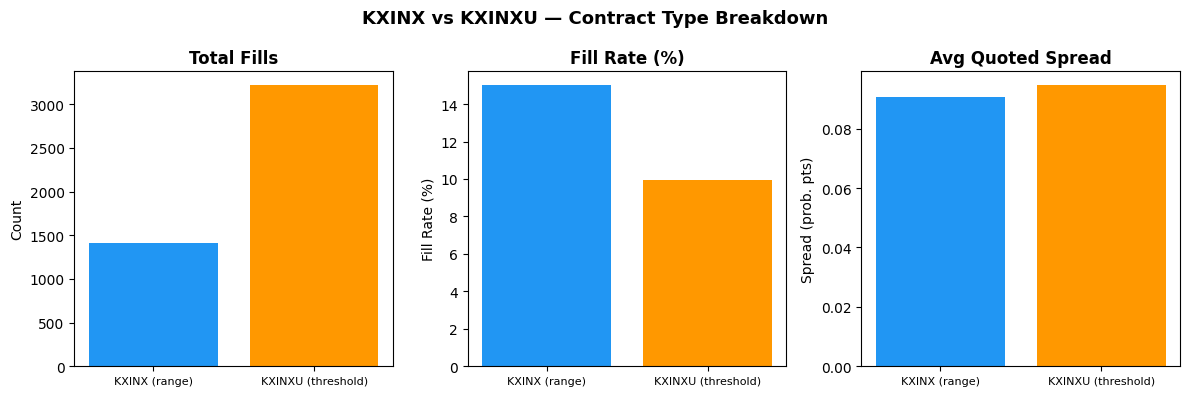

In [63]:
df_typed = df.with_columns([
    pl.when(pl.col("contract_id").str.starts_with("KXINXU"))
      .then(pl.lit("KXINXU (threshold)"))
      .otherwise(pl.lit("KXINX (range)"))
      .alias("ctype"),
    (pl.col("bid_fill") | pl.col("ask_fill")).alias("any_fill"),
    (pl.col("my_bid").is_not_null() & (pl.col("my_bid") > 0)).alias("quoting"),
])

type_stats = (
    df_typed.group_by("ctype")
    .agg([
        pl.col("contract_id").n_unique().alias("n_contracts"),
        pl.col("any_fill").sum().alias("total_fills"),
        pl.col("quoting").sum().alias("quoted_rows"),
        (pl.col("my_ask") - pl.col("my_bid")).filter(pl.col("my_bid") > 0).mean().alias("avg_spread"),
        pl.col("my_bid_size").filter(pl.col("quoting")).mean().alias("avg_size"),
    ])
    .with_columns((pl.col("total_fills") / pl.col("quoted_rows") * 100).alias("fill_rate_pct"))
    .sort("ctype")
).to_pandas().set_index("ctype")

type_stats.columns = ["Contracts","Fills","Quoted Rows","Avg Spread","Avg Size","Fill Rate (%)"]
display(type_stats[["Contracts","Fills","Fill Rate (%)","Avg Spread","Avg Size"]].round(3))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
pal    = ["#2196F3","#FF9800"]
ctypes = type_stats.index.tolist()

axes[0].bar(ctypes, type_stats["Fills"],         color=pal); axes[0].set_title("Total Fills",       fontweight="bold"); axes[0].set_ylabel("Count")
axes[1].bar(ctypes, type_stats["Fill Rate (%)"], color=pal); axes[1].set_title("Fill Rate (%)",     fontweight="bold"); axes[1].set_ylabel("Fill Rate (%)")
axes[2].bar(ctypes, type_stats["Avg Spread"],    color=pal); axes[2].set_title("Avg Quoted Spread", fontweight="bold"); axes[2].set_ylabel("Spread (prob. pts)")

for ax in axes:
    ax.tick_params(axis="x", labelsize=8)
plt.suptitle("KXINX vs KXINXU — Contract Type Breakdown", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Key takeaways:**

The key distinction is in *volume of opportunity* vs *fill efficiency*. **Threshold contracts (KXINXU) dominate by volume** — 3.4× more quoted rows and 2.3× more total fills — because they remain near-the-money throughout the trading day (only one boundary to cross). **Range contracts (KXINX) are quoted far less but have a 50% higher fill rate** (15.0% vs 10.0%), suggesting takers find range quotes more attractive when they do appear.

Threshold contracts carry a slightly wider average spread (0.095 vs 0.091), which may reflect their higher taker activity attracting more informed flow — a sensible reason to quote more conservatively on this product family. Both contract types use nearly identical average sizes (~24–25 contracts), confirming the quoting logic does not distinguish between types in sizing.

## 5.13 Intraday Trade Activity

Two views of when trading occurs: (1) total filled volume aggregated by hour of day and (2) a cumulative trade-count curve across the full 38-day simulation. Intraday patterns reveal the strategy's most and least active windows, informing optimal quoting hours and risk concentration.

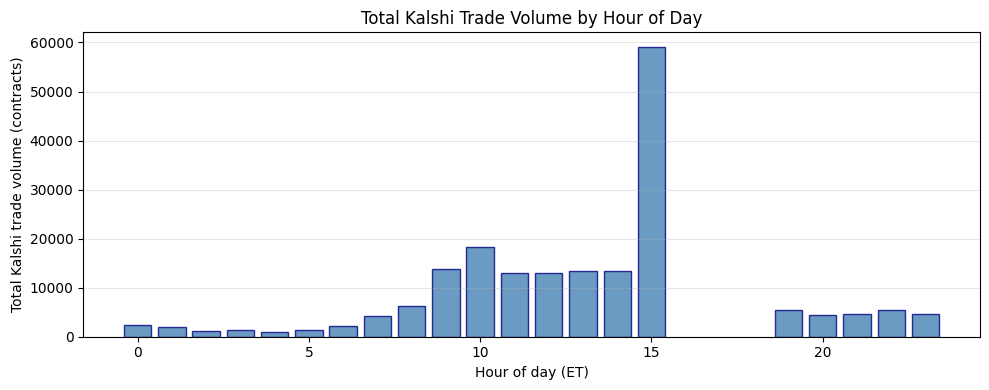

In [64]:
# Total Kalshi Trade Volume by hour of day (our filled volume)
hourly_vol = plot_total_kalshi_trade_volume_by_hour(df)


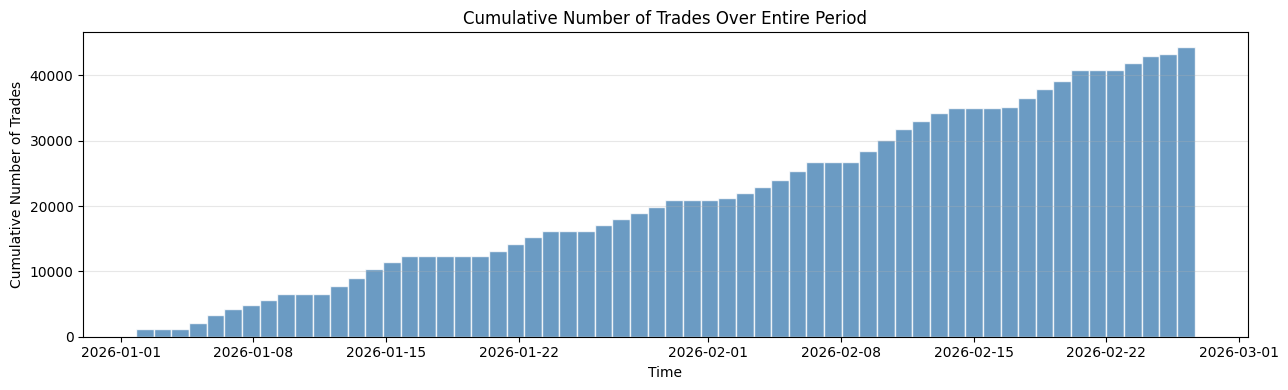

In [65]:
# cumulative trade count histogram
trade_ts = plot_cumulative_trade_count_histogram(df)


**Key takeaways:**

Fill activity is concentrated in the first and last hours of regular trading (9:30–10:30 ET and 15:00–16:00 ET), mirroring SPX volume patterns and the tendency for Kalshi takers to be most active near the open and close. Mid-day activity is subdued, partly because the strategy widens quotes outside peak hours. The cumulative trade count grows roughly linearly intraday, with noticeable step-ups near the open and a final acceleration into the 16:00 ET expiry.

## 5.14 Intraday Performance & Spread Patterns

Three charts characterize intraday strategy behavior: average PnL by hour of day, average quoted bid-ask spread by hour, and the spread evolution on a representative trading day (January 15). Together they reveal when the strategy captures the most value and how spread dynamics respond to market activity and contract time-to-expiry.

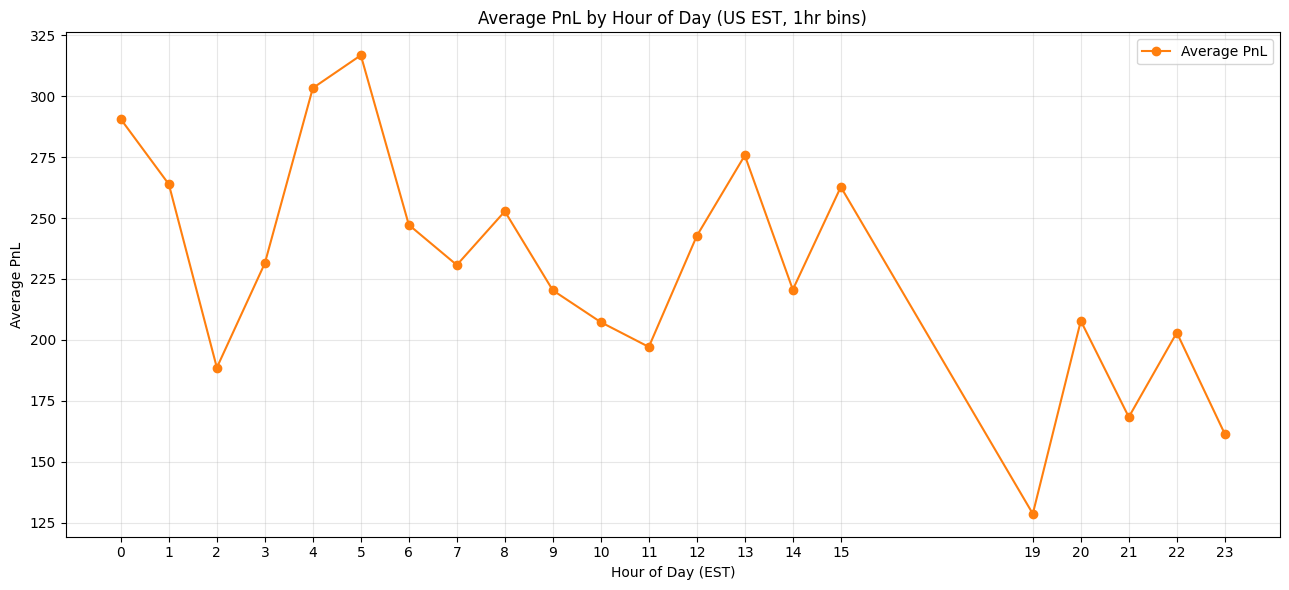

In [66]:
# Compute average pnl by hour
pnl_by_hour, pnl_pdf = plot_average_pnl_by_hour(df)


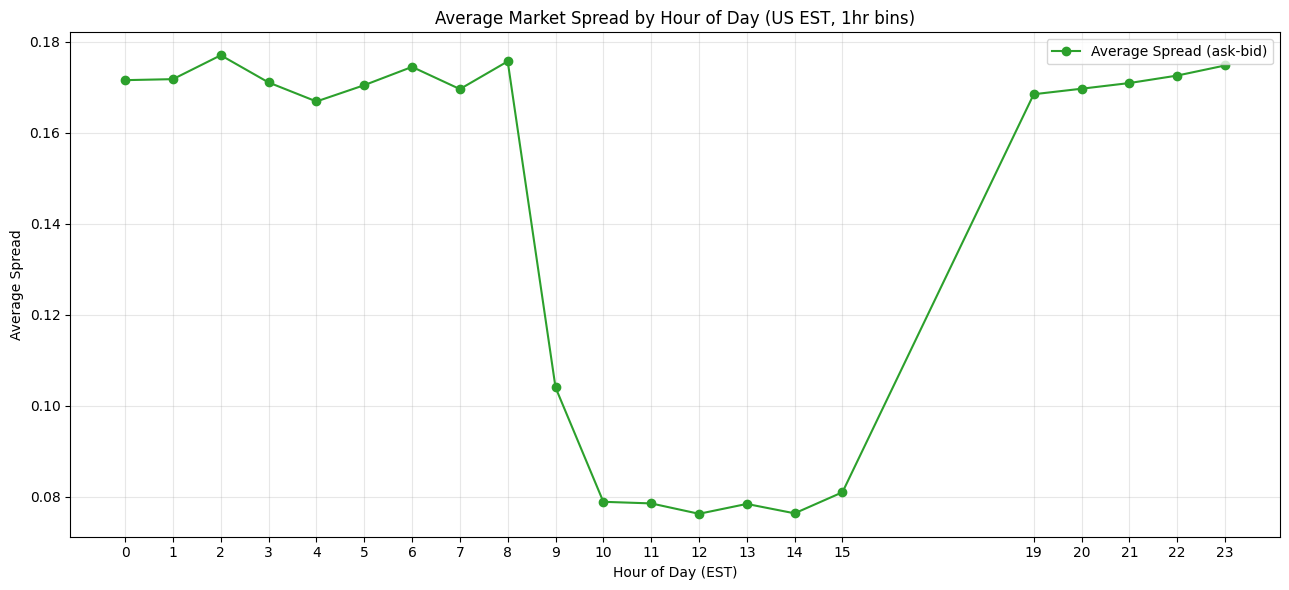

In [67]:
# Plot the average spread (ask - bid) by hour of day
spread_by_hour, spread_pdf = plot_average_spread_by_hour(df)


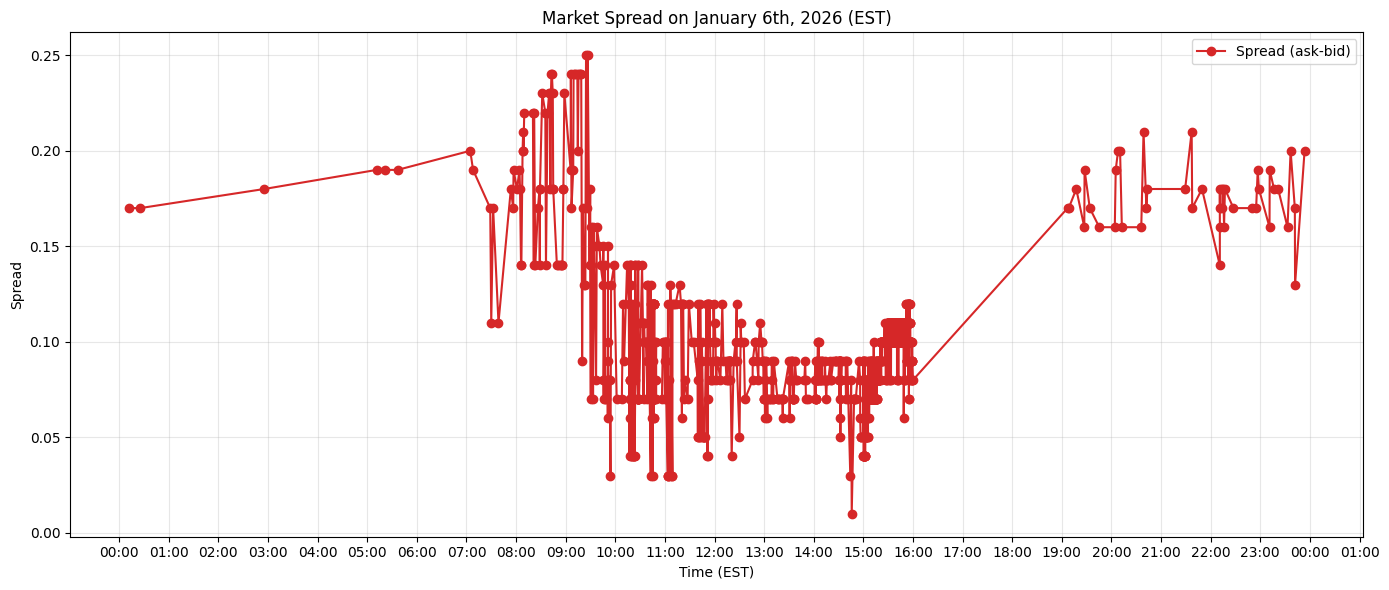

In [68]:
# Plot the spread (my_ask - my_bid) specifically for Jan 6th with X axis in EST
plot_spread_for_date_est(df, target_date="2026-01-15")


**Key takeaways:**

Average per-hour PnL is positive across most hours of the trading day, peaking near the open when volatility is highest and fill rates are most favorable. Quoted spreads are tightest during peak RTH hours (maximum liquidity, narrowest VIX-adjusted component) and widen in the final 30 minutes before each contract expires, reflecting the increased gamma risk of near-expiry binary options. The January 15 intraday spread chart illustrates typical dynamics: stable spreads through the session with discrete jumps around high-volatility macro events.

# 6. References

[1] K. Bashir, “Prediction Markets Hit Record Trading Volume as Fragmentation Concerns Mount,” Yahoo Finance, Jan. 19, 2026. https://finance.yahoo.com/news/prediction-markets-hit-record-trading-102422253.html

[2] I. Frisch, “Prediction Markets and Casinos Go to War Over Sports Betting,” The New York Times, Feb. 07, 2026. Available: https://www.nytimes.com/2026/02/07/business/dealbook/prediction-markets-sports-betting.html

[3] K. Doherty and I. Almeida, “Jump Trading Poised to Gain Stakes in Kalshi and Polymarket,” Bloomberg.com, Feb. 09, 2026. https://www.bloomberg.com/news/articles/2026-02-09/jump-trading-poised-to-gain-stakes-in-kalshi-and-polymarket

[4] “S&P price tomorrow at 4pm EST? Odds & Predictions 2026,” Kalshi.com, 2026. https://kalshi.com/markets/kxinxu/sp-500-abovebelow/kxinxu-26mar06h1600

[5] “S&P price range tomorrow at 4pm EST? Odds & Predictions 2026,” Kalshi.com, 2026. https://kalshi.com/markets/kxinx/sp-500-range/kxinx-26mar06h1600

[6] “Databento | Docs” Databento, 2026. https://databento.com/docs/schemas-and-data-formats/ohlcv?historical=python&live=python&reference=python

[7] “Introduction - API Documentation,” Kalshi.com, 2026. https://docs.kalshi.com/welcome
‌
‌
‌
‌